In [1]:
print("[1/16] Installing dependencies and configuring the GPU-aware pipeline...")

%pip install -q --upgrade rapidfuzz lightgbm xgboost sentence-transformers faiss-cpu pyarrow psutil cloudpickle
# cuML/RAPIDS proxy serialization in this notebook expects the vendored
# joblib.externals.cloudpickle path that was removed in joblib 1.6.
%pip install -q "joblib==1.5.3"

# RAPIDS is optional but enables zero-code GPU acceleration for compatible
# scikit-learn estimators and preprocessing. Installation is attempted only
# when an NVIDIA runtime is visible. Unsupported operations safely remain on CPU.
import os, sys, subprocess, shutil, re, json, math, random, time, warnings, unicodedata, gc
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations
from dataclasses import dataclass

AUTO_INSTALL_RAPIDS = True
NVIDIA_RUNTIME_VISIBLE = shutil.which("nvidia-smi") is not None
RAPIDS_INSTALL_ATTEMPTED = False
RAPIDS_INSTALL_ERROR = None

if NVIDIA_RUNTIME_VISIBLE and AUTO_INSTALL_RAPIDS:
    try:
        import cuml  # noqa: F401
    except Exception:
        RAPIDS_INSTALL_ATTEMPTED = True
        try:
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", "-q",
                "--extra-index-url", "https://pypi.nvidia.com", "cuml-cu12"
            ])
        except Exception as exc:
            RAPIDS_INSTALL_ERROR = str(exc)
            print("RAPIDS installation was unavailable; scikit-learn will use CPU fallbacks.")

# cuml.accel must be enabled before importing scikit-learn.
CUML_ACCEL_ACTIVE = False
if NVIDIA_RUNTIME_VISIBLE:
    try:
        import cuml
        cuml.accel.install()
        CUML_ACCEL_ACTIVE = True
    except Exception as exc:
        if RAPIDS_INSTALL_ERROR is None:
            RAPIDS_INSTALL_ERROR = str(exc)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import psutil

# Fail early if a future environment ignores the pin above.
if tuple(int(x) for x in joblib.__version__.split(".")[:2]) >= (1, 6):
    raise RuntimeError(
        f"Incompatible joblib {joblib.__version__}. This notebook requires joblib==1.5.3 "
        "for RAPIDS/cuml.accel model serialization. Restart the runtime after Cell 1."
    )

from rapidfuzz import fuzz
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_fscore_support,
    brier_score_loss, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

try:
    import torch
except Exception:
    torch = None

try:
    import cupy as cp
    CUPY_AVAILABLE = True
except Exception:
    cp = None
    CUPY_AVAILABLE = False

try:
    import faiss
    FAISS_AVAILABLE = True
    FAISS_GPU_AVAILABLE = bool(
        NVIDIA_RUNTIME_VISIBLE
        and hasattr(faiss, "StandardGpuResources")
        and hasattr(faiss, "index_cpu_to_gpu")
    )
except Exception:
    FAISS_AVAILABLE = False
    FAISS_GPU_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    ST_AVAILABLE = True
except Exception:
    ST_AVAILABLE = False

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running in Google Colab; Drive mount skipped.")

BASE_PATH = os.environ.get("ENTITY_DATA_PATH", "data/private/people.csv")
OUTPUT_DIR = Path(os.environ.get("ENTITY_OUTPUT_DIR", "artifacts/gpu_pipeline_v5_5_optimized"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# -----------------------------
# Runtime controls
# -----------------------------
RANDOM_STATE = 42

# Development mode avoids accidentally constructing a very large pair table.
# Set RUN_FULL_CORPUS=True only when the CPU/RAM-heavy preprocessing stages have
# enough resources; GPU acceleration does not remove those host-side costs.
RUN_FULL_CORPUS = False
MAX_LABELED_ROWS = None if RUN_FULL_CORPUS else 30_000
MAX_UNLABELED_AUDIT_ROWS = 5_000
MAX_POS_DIRECTED_PER_PERSON = 20
NEGATIVES_PER_POSITIVE = 4
MAX_VALIDATION_UTILITY_QUERIES = 300
MAX_VALIDATION_RANKING_QUERIES = 250
MAX_TEST_RANKING_QUERIES = 500
MAX_DISTRACTOR_QUERIES = 250

FULL_SCORE_BUDGET = 700
PRE_RANK_K = 350
CHANNEL_RAW_CAP = 1_000
CHANNEL_FLOOR = 10
CHANNEL_CAP = 250
LEXICAL_TOP_K = 250
VECTOR_TOP_K = 250

ENABLE_EMBEDDINGS = True
EMBEDDING_MODEL_NAME = "intfloat/e5-small-v2"
USE_FP16_EMBEDDINGS = True
USE_PCA = False
PCA_COMPONENTS = 128

# GPU controls
GPU_ID = 0
USE_GPU = bool(torch is not None and torch.cuda.is_available())
DEVICE = f"cuda:{GPU_ID}" if USE_GPU else "cpu"
GPU_NAME = torch.cuda.get_device_name(GPU_ID) if USE_GPU else None
GPU_VRAM_GB = (
    torch.cuda.get_device_properties(GPU_ID).total_memory / (1024 ** 3)
    if USE_GPU else 0.0
)

# Conservative automatic embedding batch size. The encoding helper retries with
# smaller batches after CUDA OOM rather than terminating the notebook.
if USE_GPU and GPU_VRAM_GB >= 30:
    EMBED_BATCH_SIZE = 1536
elif USE_GPU and GPU_VRAM_GB >= 20:
    EMBED_BATCH_SIZE = 1024
elif USE_GPU and GPU_VRAM_GB >= 12:
    EMBED_BATCH_SIZE = 512
else:
    EMBED_BATCH_SIZE = 256
MIN_EMBED_BATCH_SIZE = 32

TARGET_AUTO_PRECISION = 0.995
TARGET_CANDIDATE_RECALL = 0.95

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch is not None:
    torch.manual_seed(RANDOM_STATE)
    if USE_GPU:
        torch.cuda.manual_seed_all(RANDOM_STATE)
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass


def release_gpu_memory():
    """Release temporary Python/CUDA allocations between large pipeline stages."""
    gc.collect()
    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
    if CUPY_AVAILABLE:
        try:
            cp.get_default_memory_pool().free_all_blocks()
            cp.get_default_pinned_memory_pool().free_all_blocks()
        except Exception:
            pass


def gpu_memory_snapshot():
    if not USE_GPU:
        return {"allocated_gb": 0.0, "reserved_gb": 0.0}
    return {
        "allocated_gb": float(torch.cuda.memory_allocated(GPU_ID) / (1024 ** 3)),
        "reserved_gb": float(torch.cuda.memory_reserved(GPU_ID) / (1024 ** 3)),
    }

print(f"Dataset: {BASE_PATH}")
print(f"Output:  {OUTPUT_DIR}")
print(f"Device: {DEVICE}; GPU: {GPU_NAME}; VRAM: {GPU_VRAM_GB:.1f} GB")
print(f"RAPIDS accelerator: {CUML_ACCEL_ACTIVE}; CuPy: {CUPY_AVAILABLE}")
print(f"FAISS CPU: {FAISS_AVAILABLE}; FAISS GPU: {FAISS_GPU_AVAILABLE}; SentenceTransformers: {ST_AVAILABLE}")
if RAPIDS_INSTALL_ERROR:
    print(f"RAPIDS note: {RAPIDS_INSTALL_ERROR[:300]}")
print("[1/16] GPU-aware setup complete.")


[1/16] Installing dependencies and configuring the GPU-aware pipeline...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: ${ENTITY_DATA_PATH}
Output:  artifacts/gpu_pipeline_v5_5_optimized
Device: cuda:0; GPU: Tesla T4; VRAM: 14.6 GB
RAPIDS accelerator: True; CuPy: True
FAISS CPU: True; FAISS GPU: False; SentenceTransformers: True
[1/16] GPU-aware setup complete.


In [2]:
# ============================================================
# CELL 2: Load data and run schema / ground-truth audit
# ============================================================
print("[2/16] Loading data and auditing schema...")
start = time.time()
raw_df = pd.read_csv(BASE_PATH, low_memory=False)
raw_df["row_uid"] = np.arange(len(raw_df), dtype=np.int64)

required = ["id", "person"]
missing_required = [c for c in required if c not in raw_df.columns]
if missing_required:
    raise ValueError(f"Required columns are missing: {missing_required}")

optional_columns = [
    "heimild", "nafn_norm", "first_name", "middle_name", "patronym", "surname",
    "birthyear", "sex", "status", "marriagestatus", "partner", "father", "mother",
    "source_partner", "source_father", "source_mother", "source_farm", "farm",
    "county", "parish", "district", "father_name", "mother_name", "partner_name",
    "maiden_name", "married_name", "aliases", "deathyear"
]
for col in optional_columns:
    if col not in raw_df.columns:
        raw_df[col] = np.nan

person_numeric = pd.to_numeric(raw_df["person"], errors="coerce")
raw_df["person_id"] = person_numeric.astype("Int64").astype("string")
raw_df.loc[person_numeric.isna(), "person_id"] = pd.NA

person_counts = raw_df["person_id"].value_counts(dropna=True)
print(f"Rows: {len(raw_df):,}")
print(f"Labeled rows: {raw_df['person_id'].notna().sum():,}")
print(f"Unlabeled rows: {raw_df['person_id'].isna().sum():,}")
print(f"Unique labeled persons: {raw_df['person_id'].nunique(dropna=True):,}")
print(f"Persons with >=2 records: {(person_counts >= 2).sum():,}")
print(f"Rows belonging to duplicate persons: {person_counts[person_counts >= 2].sum():,}")
print(f"Load time: {time.time() - start:.1f}s")
print("[2/16] Schema audit complete.")

[2/16] Loading data and auditing schema...
Rows: 984,028
Labeled rows: 493,681
Unlabeled rows: 490,347
Unique labeled persons: 226,864
Persons with >=2 records: 106,168
Rows belonging to duplicate persons: 372,985
Load time: 5.0s
[2/16] Schema audit complete.


In [3]:
# ============================================================
# CELL 3: Deterministic cleaning and metadata policy
# ============================================================
print("[3/16] Cleaning names, years, locations, and preserving audit fields...")

TEXT_FIELDS = [
    "nafn_norm", "first_name", "middle_name", "patronym", "surname", "sex",
    "status", "marriagestatus", "father_name", "mother_name", "partner_name",
    "maiden_name", "married_name", "aliases"
]
LOCATION_FIELDS = ["county", "parish", "district", "farm"]
SOURCE_FIELDS = ["heimild", "source_partner", "source_father", "source_mother", "source_farm"]


def normalize_text(value, ascii_fold=False):
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value)).lower().strip()
    text = re.sub(r"[^\w\s\-']+", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    if ascii_fold:
        text = unicodedata.normalize("NFKD", text)
        text = "".join(ch for ch in text if not unicodedata.combining(ch))
        text = text.encode("ascii", "ignore").decode("ascii")
        text = re.sub(r"\s+", " ", text).strip()
    return text


def numeric_key(series):
    values = pd.to_numeric(series, errors="coerce").astype("Int64").astype("string")
    return values.fillna("unk")


def normalize_sex(value):
    text = normalize_text(value, ascii_fold=True)
    if text in {"m", "male", "man", "karl", "kk"} or "karl" in text:
        return "m"
    if text in {"f", "female", "woman", "kona", "kvk"} or "kona" in text:
        return "f"
    return ""


def soundex_token(value):
    """Small ASCII Soundex fallback; used for retrieval only, never as ground truth."""
    value = normalize_text(value, ascii_fold=True).upper()
    value = re.sub(r"[^A-Z]", "", value)
    if not value:
        return ""
    first = value[0]
    groups = {
        **{c: "1" for c in "BFPV"}, **{c: "2" for c in "CGJKQSXZ"},
        **{c: "3" for c in "DT"}, **{c: "4" for c in "L"},
        **{c: "5" for c in "MN"}, **{c: "6" for c in "R"}
    }
    digits, prev = [], groups.get(first, "")
    for ch in value[1:]:
        d = groups.get(ch, "")
        if d and d != prev:
            digits.append(d)
        prev = d
    return (first + "".join(digits) + "000")[:4]


def clean_records(frame):
    out = frame.copy()
    for col in TEXT_FIELDS:
        out[f"{col}_clean"] = out[col].map(lambda x: normalize_text(x, ascii_fold=False))
        out[f"{col}_ascii"] = out[col].map(lambda x: normalize_text(x, ascii_fold=True))

    out["sex_norm"] = out["sex"].map(normalize_sex)

    out["birthyear_num"] = pd.to_numeric(out["birthyear"], errors="coerce")
    invalid_year = (out["birthyear_num"] < 1200) | (out["birthyear_num"] > 2026)
    out.loc[invalid_year, "birthyear_num"] = np.nan
    out["deathyear_num"] = pd.to_numeric(out["deathyear"], errors="coerce")
    invalid_death = (out["deathyear_num"] < 1200) | (out["deathyear_num"] > 2026)
    out.loc[invalid_death, "deathyear_num"] = np.nan
    out["birth_decade"] = (out["birthyear_num"] // 10 * 10).astype("Int64").astype("string").fillna("unk")

    for col in LOCATION_FIELDS + SOURCE_FIELDS:
        out[f"{col}_key"] = numeric_key(out[col])

    fallback_clean = (
        out["first_name_clean"].str.cat(out["middle_name_clean"], sep=" ")
        .str.cat(out["patronym_clean"], sep=" ")
        .str.cat(out["surname_clean"], sep=" ")
        .str.replace(r"\s+", " ", regex=True).str.strip()
    )
    out["full_name_clean"] = out["nafn_norm_clean"].where(out["nafn_norm_clean"].ne(""), fallback_clean)

    fallback_ascii = (
        out["first_name_ascii"].str.cat(out["middle_name_ascii"], sep=" ")
        .str.cat(out["patronym_ascii"], sep=" ")
        .str.cat(out["surname_ascii"], sep=" ")
        .str.replace(r"\s+", " ", regex=True).str.strip()
    )
    out["full_name_ascii"] = out["nafn_norm_ascii"].where(out["nafn_norm_ascii"].ne(""), fallback_ascii)

    out["family_name_ascii"] = out["patronym_ascii"].where(out["patronym_ascii"].ne(""), out["surname_ascii"])
    out["first_initial"] = out["first_name_ascii"].str[:1].replace("", "_")
    out["family_initial"] = out["family_name_ascii"].str[:1].replace("", "_")
    out["first_soundex"] = out["first_name_ascii"].map(soundex_token)
    out["family_soundex"] = out["family_name_ascii"].map(soundex_token)

    out["record_text"] = (
        "first_name: " + out["first_name_clean"]
        + " | middle_name: " + out["middle_name_clean"]
        + " | patronym: " + out["patronym_clean"]
        + " | surname: " + out["surname_clean"]
        + " | maiden_name: " + out["maiden_name_clean"]
        + " | married_name: " + out["married_name_clean"]
        + " | birthyear: " + out["birthyear_num"].fillna(-1).astype(int).astype(str)
        + " | sex: " + out["sex_norm"]
        + " | county: " + out["county_key"]
        + " | parish: " + out["parish_key"]
        + " | district: " + out["district_key"]
        + " | farm: " + out["farm_key"]
        + " | father_name: " + out["father_name_clean"]
        + " | mother_name: " + out["mother_name_clean"]
        + " | partner_name: " + out["partner_name_clean"]
    )

    quality_fields = [
        out["first_name_clean"].ne(""), out["family_name_ascii"].ne(""),
        out["birthyear_num"].notna(), out["sex_norm"].ne(""),
        out["county_key"].ne("unk"), out["parish_key"].ne("unk"),
        out["farm_key"].ne("unk"), out["full_name_clean"].ne("")
    ]
    out["info_quality"] = np.mean(np.column_stack(quality_fields), axis=1).astype(np.float32)
    return out

def sample_complete_identity_groups_raw(frame, target_rows, random_state=42):
    """Development sampling that never cuts an identity group in half."""
    if target_rows is None or len(frame) <= target_rows:
        return frame.copy()
    rng = np.random.default_rng(random_state)
    counts = frame["person_id"].value_counts()
    duplicate_ids = counts[counts >= 2].index.to_numpy()
    singleton_ids = counts[counts == 1].index.to_numpy()
    rng.shuffle(duplicate_ids)
    rng.shuffle(singleton_ids)

    selected, used_rows = [], 0
    duplicate_budget = int(target_rows * 0.85)
    for pid in duplicate_ids:
        group_size = int(counts.loc[pid])
        if used_rows + group_size > duplicate_budget and selected:
            continue
        selected.append(pid)
        used_rows += group_size
        if used_rows >= duplicate_budget:
            break
    for pid in singleton_ids:
        if used_rows >= target_rows:
            break
        selected.append(pid)
        used_rows += 1
    return frame[frame["person_id"].isin(selected)].copy()

# Avoided normalizing all 984k rows in a development notebook. Sample complete labeled
# identities first, then clean every selected record before splitting. Full production
# index builds should use a batched Polars/SQL job rather than one giant pandas frame.
raw_labeled = raw_df[raw_df["person_id"].notna()].copy()
raw_unlabeled = raw_df[raw_df["person_id"].isna()].copy()
raw_labeled_sample = sample_complete_identity_groups_raw(raw_labeled, MAX_LABELED_ROWS, RANDOM_STATE)
if MAX_UNLABELED_AUDIT_ROWS is not None and len(raw_unlabeled) > MAX_UNLABELED_AUDIT_ROWS:
    raw_unlabeled_sample = raw_unlabeled.sample(MAX_UNLABELED_AUDIT_ROWS, random_state=RANDOM_STATE)
else:
    raw_unlabeled_sample = raw_unlabeled.copy()

labeled_df = clean_records(raw_labeled_sample)
unlabeled_audit_df = clean_records(raw_unlabeled_sample)
del raw_labeled, raw_unlabeled, raw_labeled_sample, raw_unlabeled_sample

print(f"Clean labeled development rows: {len(labeled_df):,}")
print(f"Open-world unlabeled audit rows: {len(unlabeled_audit_df):,}")
print("Raw source fields are retained for audit/splitting but excluded from model features.")
print("Internal father/mother/partner/farm IDs are excluded from predictive features.")
print("[3/16] Cleaning complete.")

[3/16] Cleaning names, years, locations, and preserving audit fields...
Clean labeled development rows: 30,000
Open-world unlabeled audit rows: 5,000
Raw source fields are retained for audit/splitting but excluded from model features.
Internal father/mother/partner/farm IDs are excluded from predictive features.
[3/16] Cleaning complete.


In [4]:
# ============================================================
# CELL 4: Complete-group sampling and identity-safe four-way split
# ============================================================
print("[4/16] Sampling complete identity groups and splitting by person ID...")


# Labeled records were sampled by complete person groups before expensive cleaning.
sampled_df = labeled_df.sort_values("row_uid").reset_index(drop=True)

def group_split(frame, test_size, random_state):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    left_idx, right_idx = next(splitter.split(frame, groups=frame["person_id"]))
    return frame.iloc[left_idx].copy(), frame.iloc[right_idx].copy()

# Approximate identity-safe proportions: 60% train, 15% calibration, 10% validation, 15% test
remaining, test_df = group_split(sampled_df, test_size=0.15, random_state=RANDOM_STATE)
remaining, valid_df = group_split(remaining, test_size=0.10 / 0.85, random_state=RANDOM_STATE + 1)
train_df, calibration_df = group_split(remaining, test_size=0.15 / 0.75, random_state=RANDOM_STATE + 2)

splits = {
    "train": train_df.reset_index(drop=True),
    "calibration": calibration_df.reset_index(drop=True),
    "validation": valid_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}

for name, split_df in splits.items():
    split_df["local_idx"] = np.arange(len(split_df), dtype=np.int64)
    split_df["first_name_frequency"] = split_df["first_name_ascii"].map(split_df["first_name_ascii"].value_counts())
    split_df["duplicate_count"] = split_df["person_id"].map(split_df["person_id"].value_counts())
    splits[name] = split_df

person_sets = {name: set(frame["person_id"]) for name, frame in splits.items()}
for a in person_sets:
    for b in person_sets:
        if a < b:
            overlap = person_sets[a] & person_sets[b]
            assert not overlap, f"Identity leakage between {a} and {b}: {len(overlap)} persons"

print(f"Sampled rows: {len(sampled_df):,}; persons: {sampled_df['person_id'].nunique():,}")
for name, frame in splits.items():
    dup_people = (frame["person_id"].value_counts() >= 2).sum()
    print(f"{name:12s}: rows={len(frame):,}, persons={frame['person_id'].nunique():,}, duplicate persons={dup_people:,}")
print("Identity overlap audit: PASS")
print("[4/16] Split complete.")

[4/16] Sampling complete identity groups and splitting by person ID...
Sampled rows: 30,000; persons: 11,743
train       : rows=17,952, persons=7,044, duplicate persons=4,364
calibration : rows=4,550, persons=1,762, duplicate persons=1,103
validation  : rows=2,974, persons=1,175, duplicate persons=709
test        : rows=4,524, persons=1,762, duplicate persons=1,067
Identity overlap audit: PASS
[4/16] Split complete.


In [5]:
# ============================================================
# CELL 5: Build train-only lexical objects and GPU embeddings
# ============================================================
print("[5/16] Fitting train-only lexical objects and GPU-accelerated embeddings...")

# Character TF-IDF remains sparse and CPU-resident. With cuml.accel enabled,
# compatible nearest-neighbor operations may be dispatched to GPU automatically;
# otherwise this stage safely uses the CPU.
tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 5),
    min_df=2,
    max_features=200_000,
    lowercase=False,
    dtype=np.float32,
)
X_tfidf = {}
X_tfidf["train"] = tfidf.fit_transform(splits["train"]["record_text"].fillna(""))
for name in ["calibration", "validation", "test"]:
    X_tfidf[name] = tfidf.transform(splits[name]["record_text"].fillna(""))

lexical_nn = {}
for name, matrix in X_tfidf.items():
    nn = NearestNeighbors(metric="cosine", algorithm="brute", n_jobs=-1)
    nn.fit(matrix)
    lexical_nn[name] = nn

embedding_model = None
query_embeddings = {name: None for name in splits}
passage_embeddings = {name: None for name in splits}
vector_indexes = {name: None for name in splits}
faiss_gpu_resources = {}
pca = None


def encode_with_oom_backoff(texts, description):
    """Encode on GPU and halve the batch size if VRAM is insufficient."""
    batch_size = EMBED_BATCH_SIZE
    while True:
        try:
            with torch.inference_mode() if torch is not None else nullcontext():
                encoded = embedding_model.encode(
                    texts,
                    batch_size=batch_size,
                    show_progress_bar=True,
                    normalize_embeddings=True,
                    convert_to_numpy=True,
                    device=DEVICE,
                )
            return np.ascontiguousarray(encoded, dtype=np.float32), batch_size
        except RuntimeError as exc:
            is_oom = "out of memory" in str(exc).lower() or "cuda" in str(exc).lower()
            if not (USE_GPU and is_oom and batch_size > MIN_EMBED_BATCH_SIZE):
                raise
            batch_size = max(MIN_EMBED_BATCH_SIZE, batch_size // 2)
            print(f"  CUDA memory pressure during {description}; retrying with batch_size={batch_size}")
            release_gpu_memory()


# nullcontext is used when torch is unavailable.
from contextlib import nullcontext

if ENABLE_EMBEDDINGS and ST_AVAILABLE:
    print(f"Loading {EMBEDDING_MODEL_NAME} on {DEVICE}...")
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)
    embedding_model.eval()
    if USE_GPU and USE_FP16_EMBEDDINGS:
        try:
            embedding_model.half()
            print("Embedding model uses FP16 inference.")
        except Exception as exc:
            print(f"FP16 was not supported by this model; using FP32. ({exc})")

    for name, frame in splits.items():
        print(f"  Encoding {name}: {len(frame):,} records")
        query_texts = ("query: " + frame["record_text"].fillna("")).tolist()
        passage_texts = ("passage: " + frame["record_text"].fillna("")).tolist()
        query_embeddings[name], query_bs = encode_with_oom_backoff(query_texts, f"{name} queries")
        passage_embeddings[name], passage_bs = encode_with_oom_backoff(passage_texts, f"{name} passages")
        print(f"    completed with query batch={query_bs}, passage batch={passage_bs}")
        del query_texts, passage_texts
        release_gpu_memory()

    if USE_PCA:
        from sklearn.decomposition import PCA
        n_components = min(PCA_COMPONENTS, passage_embeddings["train"].shape[1], len(splits["train"]) - 1)
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        pca.fit(np.vstack([query_embeddings["train"], passage_embeddings["train"]]))
        for name in splits:
            query_embeddings[name] = pca.transform(query_embeddings[name]).astype(np.float32)
            passage_embeddings[name] = pca.transform(passage_embeddings[name]).astype(np.float32)
            query_embeddings[name] /= np.linalg.norm(query_embeddings[name], axis=1, keepdims=True) + 1e-12
            passage_embeddings[name] /= np.linalg.norm(passage_embeddings[name], axis=1, keepdims=True) + 1e-12

    for name, embeddings in passage_embeddings.items():
        if FAISS_GPU_AVAILABLE and USE_GPU:
            # Exact inner-product search is fast on GPU and uses normalized vectors,
            # so inner product equals cosine similarity.
            dim = embeddings.shape[1]
            resources = faiss.StandardGpuResources()
            cpu_index = faiss.IndexFlatIP(dim)
            try:
                options = faiss.GpuClonerOptions()
                options.useFloat16 = True
                gpu_index = faiss.index_cpu_to_gpu(resources, GPU_ID, cpu_index, options)
            except Exception:
                gpu_index = faiss.index_cpu_to_gpu(resources, GPU_ID, cpu_index)
            gpu_index.add(np.ascontiguousarray(embeddings))
            faiss_gpu_resources[name] = resources  # keep resources alive
            vector_indexes[name] = gpu_index
        elif FAISS_AVAILABLE:
            dim = embeddings.shape[1]
            index = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
            index.hnsw.efConstruction = 200
            index.hnsw.efSearch = 64
            index.add(np.ascontiguousarray(embeddings))
            vector_indexes[name] = index
        else:
            nn = NearestNeighbors(metric="cosine", algorithm="brute", n_jobs=-1)
            nn.fit(embeddings)
            vector_indexes[name] = nn
else:
    print("Embeddings disabled or SentenceTransformers unavailable; lexical + structured baseline remains active.")

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Embedding feature active: {embedding_model is not None}")
print(f"Vector index backend: {'FAISS-GPU' if FAISS_GPU_AVAILABLE and USE_GPU else 'FAISS/CPU fallback'}")
print("[5/16] Text representations complete.")

[5/16] Fitting train-only lexical objects and GPU-accelerated embeddings...
Loading intfloat/e5-small-v2 on cuda:0...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model uses FP16 inference.
  Encoding train: 17,952 records


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

    completed with query batch=512, passage batch=512
  Encoding test: 4,524 records


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

    completed with query batch=512, passage batch=512
TF-IDF vocabulary size: 23,861
Embedding feature active: True
Vector index backend: FAISS/CPU fallback
[5/16] Text representations complete.


In [6]:
# ============================================================
# CELL 6: Multi-pass candidate indexes and retrieval utilities
# ============================================================
print("[6/16] Building compact multi-pass candidate indexes...")

CHANNELS = ["strict", "loose", "surname_free", "temporal_location", "phonetic", "lexical", "vector"]


def valid_key(*parts):
    return all(str(p) not in {"", "_", "unk", "<NA>", "nan"} for p in parts)


def append_index(mapping, key, idx):
    if key is not None:
        mapping[key].append(int(idx))


def build_candidate_indexes(frame):
    idx = {
        "strict": defaultdict(list),
        "loose": defaultdict(list),
        "surname_free": defaultdict(list),
        "temporal_county": defaultdict(list),
        "temporal_parish": defaultdict(list),
        "phonetic": defaultdict(list),
        "year_county": defaultdict(list),
        "county": defaultdict(list),
    }
    for row in frame.itertuples(index=False):
        i = int(row.local_idx)
        first = row.first_name_ascii
        family = row.family_name_ascii
        decade = str(row.birth_decade)
        county = row.county_key
        parish = row.parish_key
        year = None if pd.isna(row.birthyear_num) else int(row.birthyear_num)

        if valid_key(first, family, decade, county):
            append_index(idx["strict"], (first, family, decade, county), i)
        if valid_key(row.first_initial, row.family_initial, county):
            append_index(idx["loose"], (row.first_initial, row.family_initial, county), i)
        if valid_key(first, county):
            append_index(idx["surname_free"], (first, county), i)
        if year is not None and county != "unk":
            append_index(idx["temporal_county"], (year, county), i)
            append_index(idx["year_county"], (year, county), i)
        if year is not None and parish != "unk":
            append_index(idx["temporal_parish"], (year, parish), i)
        if valid_key(row.first_soundex, row.family_soundex, decade, county):
            append_index(idx["phonetic"], (row.first_soundex, row.family_soundex, decade, county), i)
        if county != "unk":
            append_index(idx["county"], county, i)
    return {name: dict(mapping) for name, mapping in idx.items()}

candidate_indexes = {name: build_candidate_indexes(frame) for name, frame in splits.items()}


def query_subgroup(query, frame):
    freq = int(query.get("first_name_frequency", 0) or 0)
    if freq <= 10:
        freq_bucket = "rare"
    elif freq <= 100:
        freq_bucket = "medium"
    else:
        freq_bucket = "common"
    location_missing = query.get("county_key", "unk") == "unk"
    family_missing = query.get("family_name_ascii", "") == ""
    surname_change_risk = query.get("sex_norm", "") == "f" or query.get("surname_ascii", "") == ""
    return f"freq={freq_bucket}|loc_missing={int(location_missing)}|family_missing={int(family_missing)}|surname_risk={int(surname_change_risk)}"


def cheap_pair_score(query, candidate):
    first = fuzz.WRatio(str(query.get("first_name_ascii", "")), str(candidate.get("first_name_ascii", ""))) / 100.0
    family = max(
        fuzz.WRatio(str(query.get("patronym_ascii", "")), str(candidate.get("patronym_ascii", ""))) / 100.0,
        fuzz.WRatio(str(query.get("surname_ascii", "")), str(candidate.get("surname_ascii", ""))) / 100.0,
    )
    qy, cy = query.get("birthyear_num"), candidate.get("birthyear_num")
    year = 0.0 if pd.isna(qy) or pd.isna(cy) else max(0.0, 1.0 - abs(float(qy) - float(cy)) / 20.0)
    county = float(query.get("county_key", "unk") != "unk" and query.get("county_key") == candidate.get("county_key"))
    quality = float(candidate.get("info_quality", 0.0))
    return 0.40 * first + 0.25 * family + 0.20 * year + 0.10 * county + 0.05 * quality


def retrieve_raw_channels(query, split_name, query_local_idx=None, include_expensive=True):
    frame = splits[split_name]
    indexes = candidate_indexes[split_name]
    channel_sets = {c: set() for c in CHANNELS}

    first = query.get("first_name_ascii", "")
    family = query.get("family_name_ascii", "")
    decade = str(query.get("birth_decade", "unk"))
    county = query.get("county_key", "unk")
    parish = query.get("parish_key", "unk")
    first_initial = query.get("first_initial", "_")
    family_initial = query.get("family_initial", "_")
    first_soundex = query.get("first_soundex", "")
    family_soundex = query.get("family_soundex", "")
    year = query.get("birthyear_num", np.nan)

    if valid_key(first, family, decade, county):
        channel_sets["strict"].update(indexes["strict"].get((first, family, decade, county), []))
    if valid_key(first_initial, family_initial, county):
        channel_sets["loose"].update(indexes["loose"].get((first_initial, family_initial, county), []))
    if valid_key(first, county):
        candidates = indexes["surname_free"].get((first, county), [])
        if pd.notna(year):
            candidates = [i for i in candidates if pd.isna(frame.iloc[i]["birthyear_num"]) or abs(frame.iloc[i]["birthyear_num"] - year) <= 5]
        channel_sets["surname_free"].update(candidates)
    if pd.notna(year):
        for y in range(int(year) - 5, int(year) + 6):
            if parish != "unk":
                channel_sets["temporal_location"].update(indexes["temporal_parish"].get((y, parish), []))
            if county != "unk":
                channel_sets["temporal_location"].update(indexes["temporal_county"].get((y, county), []))
    if valid_key(first_soundex, family_soundex, decade, county):
        channel_sets["phonetic"].update(indexes["phonetic"].get((first_soundex, family_soundex, decade, county), []))

    # Lexical/vector nearest-neighbor retrieval is optional for pair generation because
    # thousands of per-anchor brute-force calls are not acceptable. It remains active
    # for validation and production query retrieval.
    if include_expensive:
        if query_local_idx is not None:
            q_tfidf = X_tfidf[split_name][int(query_local_idx)]
        else:
            q_tfidf = tfidf.transform([query.get("record_text", "")])
        n_neighbors = min(LEXICAL_TOP_K + (1 if query_local_idx is not None else 0), len(frame))
        if n_neighbors > 0:
            _, neigh = lexical_nn[split_name].kneighbors(q_tfidf, n_neighbors=n_neighbors)
            channel_sets["lexical"].update(map(int, neigh[0]))

        if embedding_model is not None and vector_indexes[split_name] is not None:
            if query_local_idx is not None:
                q_emb = query_embeddings[split_name][int(query_local_idx):int(query_local_idx)+1]
            else:
                q_emb = embedding_model.encode(
                    ["query: " + query.get("record_text", "")],
                    normalize_embeddings=True, convert_to_numpy=True
                ).astype(np.float32)
                if pca is not None:
                    q_emb = pca.transform(q_emb).astype(np.float32)
                    q_emb /= np.linalg.norm(q_emb, axis=1, keepdims=True) + 1e-12
            k = min(VECTOR_TOP_K + (1 if query_local_idx is not None else 0), len(frame))
            if FAISS_AVAILABLE and hasattr(vector_indexes[split_name], "search"):
                _, neigh = vector_indexes[split_name].search(np.ascontiguousarray(q_emb), k)
                channel_sets["vector"].update(int(i) for i in neigh[0] if i >= 0)
            else:
                _, neigh = vector_indexes[split_name].kneighbors(q_emb, n_neighbors=k)
                channel_sets["vector"].update(map(int, neigh[0]))

    if query_local_idx is not None:
        for values in channel_sets.values():
            values.discard(int(query_local_idx))

    # Raw per-channel cap prevents pathological blocks before dynamic allocation.
    for channel in channel_sets:
        if len(channel_sets[channel]) > CHANNEL_RAW_CAP:
            candidates = list(channel_sets[channel])
            candidates.sort(key=lambda i: cheap_pair_score(query, frame.iloc[i]), reverse=True)
            channel_sets[channel] = set(candidates[:CHANNEL_RAW_CAP])
    return channel_sets

for name, indexes in candidate_indexes.items():
    print(f"{name:12s}: strict keys={len(indexes['strict']):,}, loose keys={len(indexes['loose']):,}, county keys={len(indexes['county']):,}")
print("[6/16] Candidate indexes complete.")

[6/16] Building compact multi-pass candidate indexes...
train       : strict keys=9,452, loose keys=7,227, county keys=262
calibration : strict keys=2,381, loose keys=2,147, county keys=248
validation  : strict keys=1,588, loose keys=1,453, county keys=237
test        : strict keys=2,374, loose keys=2,148, county keys=248
[6/16] Candidate indexes complete.


In [7]:
# ============================================================
# CELL 7: Measure candidate recall and learn dynamic channel allocation
# ============================================================
print("[7/16] Estimating retrieval-channel utility on validation identities...")


def eligible_duplicate_queries(frame, max_queries, random_state=42):
    counts = frame["person_id"].value_counts()
    eligible = frame[frame["person_id"].map(counts) >= 2]
    if len(eligible) > max_queries:
        eligible = eligible.sample(max_queries, random_state=random_state)
    return eligible


def estimate_channel_utilities(split_name="validation", max_queries=300):
    frame = splits[split_name]
    queries = eligible_duplicate_queries(frame, max_queries, RANDOM_STATE)
    stats = defaultdict(lambda: defaultdict(float))
    union_hits = 0

    for row in queries.itertuples(index=False):
        q = pd.Series(row._asdict())
        q_idx = int(q["local_idx"])
        true_ids = set(frame.index[(frame["person_id"] == q["person_id"]) & (frame["local_idx"] != q_idx)].tolist())
        channels = retrieve_raw_channels(q, split_name, q_idx)
        hit_channels = [c for c, ids in channels.items() if true_ids & ids]
        if hit_channels:
            union_hits += 1
        subgroup = query_subgroup(q, frame)
        for channel, ids in channels.items():
            stats[subgroup][f"queries::{channel}"] += 1
            stats[subgroup][f"cost::{channel}"] += len(ids)
            if channel in hit_channels:
                stats[subgroup][f"credit::{channel}"] += 1.0 / len(hit_channels)
            stats["__GLOBAL__"][f"queries::{channel}"] += 1
            stats["__GLOBAL__"][f"cost::{channel}"] += len(ids)
            if channel in hit_channels:
                stats["__GLOBAL__"][f"credit::{channel}"] += 1.0 / len(hit_channels)

    utilities = {}
    for subgroup, values in stats.items():
        utilities[subgroup] = {}
        for channel in CHANNELS:
            n = max(values.get(f"queries::{channel}", 0.0), 1.0)
            marginal = values.get(f"credit::{channel}", 0.0) / n
            average_cost = values.get(f"cost::{channel}", 0.0) / n
            utilities[subgroup][channel] = float((marginal + 1e-4) / max(average_cost, 1.0))
    recall = union_hits / max(len(queries), 1)
    return utilities, recall, len(queries)

channel_utilities, validation_candidate_recall, utility_query_count = estimate_channel_utilities(
    "validation", MAX_VALIDATION_UTILITY_QUERIES
)


def allocate_channel_slots(channel_sets, subgroup, total_budget=PRE_RANK_K):
    nonempty = [c for c in CHANNELS if channel_sets.get(c)]
    if not nonempty:
        return {c: 0 for c in CHANNELS}
    table = channel_utilities.get(subgroup, channel_utilities.get("__GLOBAL__", {}))
    floor = min(CHANNEL_FLOOR, max(1, total_budget // max(len(nonempty), 1)))
    allocation = {c: 0 for c in CHANNELS}
    for c in nonempty:
        allocation[c] = min(floor, len(channel_sets[c]), CHANNEL_CAP)
    remaining = max(0, total_budget - sum(allocation.values()))

    while remaining > 0:
        eligible = [c for c in nonempty if allocation[c] < min(CHANNEL_CAP, len(channel_sets[c]))]
        if not eligible:
            break
        weights = np.array([max(table.get(c, 1e-6), 1e-6) for c in eligible], dtype=float)
        weights /= weights.sum()
        additions = np.maximum(1, np.floor(weights * remaining).astype(int))
        progressed = 0
        for c, add in zip(eligible, additions):
            capacity = min(CHANNEL_CAP, len(channel_sets[c])) - allocation[c]
            actual = min(int(add), capacity, remaining)
            allocation[c] += actual
            remaining -= actual
            progressed += actual
            if remaining <= 0:
                break
        if progressed == 0:
            break
    return allocation


def retrieve_survivors(query, split_name, query_local_idx=None, include_expensive=True):
    frame = splits[split_name]
    channel_sets = retrieve_raw_channels(query, split_name, query_local_idx, include_expensive=include_expensive)
    union = set().union(*channel_sets.values()) if channel_sets else set()
    subgroup = query_subgroup(query, frame)

    if len(union) <= FULL_SCORE_BUDGET:
        survivors = list(union)
        mode = "full_score"
        allocation = {c: len(channel_sets[c]) for c in CHANNELS}
    else:
        allocation = allocate_channel_slots(channel_sets, subgroup, PRE_RANK_K)
        ordered = []
        provenance = defaultdict(set)
        for channel, ids in channel_sets.items():
            ranked = sorted(ids, key=lambda i: cheap_pair_score(query, frame.iloc[i]), reverse=True)
            for i in ranked[:allocation[channel]]:
                provenance[i].add(channel)
                ordered.append(i)
        survivors = list(dict.fromkeys(ordered))
        if len(survivors) > PRE_RANK_K:
            survivors.sort(key=lambda i: cheap_pair_score(query, frame.iloc[i]), reverse=True)
            survivors = survivors[:PRE_RANK_K]
        mode = "dynamic_pre_rank"

    provenance = {i: [c for c, ids in channel_sets.items() if i in ids] for i in survivors}
    return survivors, provenance, {
        "raw_candidate_count": len(union),
        "survivor_count": len(survivors),
        "retrieval_mode": mode,
        "subgroup": subgroup,
        "allocation": allocation,
    }

print(f"Validation candidate recall (union of channels): {validation_candidate_recall:.4f} over {utility_query_count} queries")
if validation_candidate_recall < TARGET_CANDIDATE_RECALL:
    print("WARNING: Candidate recall is below target. Do not promote the ranker until retrieval is improved.")
print("Global channel utilities:")
print(pd.Series(channel_utilities.get("__GLOBAL__", {})).sort_values(ascending=False))
print("[7/16] Retrieval evaluation and dynamic allocation complete.")

[7/16] Estimating retrieval-channel utility on validation identities...
Validation candidate recall (union of channels): 1.0000 over 300 queries
Global channel utilities:
phonetic             0.049600
strict               0.049573
surname_free         0.048929
loose                0.043932
temporal_location    0.025138
lexical              0.000874
vector               0.000874
dtype: float64
[7/16] Retrieval evaluation and dynamic allocation complete.


In [8]:
# ============================================================
# CELL 8: Generate supervised positives and mixed negatives
# ============================================================
print("[8/16] Generating leakage-safe supervised pairs with mixed negatives...")

NEGATIVE_MIX = {"hard": 0.70, "random": 0.20, "shortcut": 0.10}


def sample_positive_pairs(frame, max_directed_per_person=20, random_state=42):
    rng = np.random.default_rng(random_state)
    pairs = []
    for person_id, group in frame.groupby("person_id"):
        idxs = group["local_idx"].astype(int).tolist()
        if len(idxs) < 2:
            continue
        unordered = list(combinations(idxs, 2))
        rng.shuffle(unordered)
        max_unordered = max(1, max_directed_per_person // 2)
        for left, right in unordered[:max_unordered]:
            pairs.append((left, right))
            pairs.append((right, left))
    return pairs


def precompute_negative_helpers(frame):
    year_county = defaultdict(list)
    for row in frame.itertuples(index=False):
        if pd.notna(row.birthyear_num) and row.county_key != "unk":
            year_county[(int(row.birthyear_num), row.county_key)].append(int(row.local_idx))
    return {"year_county": dict(year_county), "all_indices": frame["local_idx"].astype(int).to_numpy()}


def generate_pairs(split_name, max_pos_per_person=MAX_POS_DIRECTED_PER_PERSON, negatives_per_positive=NEGATIVES_PER_POSITIVE):
    frame = splits[split_name]
    stable_split_seed = {"train": 101, "calibration": 202, "validation": 303, "test": 404}[split_name]
    rng = np.random.default_rng(RANDOM_STATE + stable_split_seed)
    positives = sample_positive_pairs(frame, max_pos_per_person, RANDOM_STATE)
    helpers = precompute_negative_helpers(frame)
    used = set()
    rows = []

    positives_by_anchor = defaultdict(list)
    for left, right in positives:
        positives_by_anchor[left].append(right)
        key = (int(left), int(right), 1)
        if key not in used:
            used.add(key)
            rows.append({"left_idx": left, "right_idx": right, "label": 1, "pair_type": "positive"})

    for anchor, positive_rights in positives_by_anchor.items():
        query = frame.iloc[int(anchor)]
        anchor_person = query["person_id"]
        target_total = max(1, len(positive_rights) * negatives_per_positive)
        targets = {
            "hard": int(round(target_total * NEGATIVE_MIX["hard"])),
            "random": int(round(target_total * NEGATIVE_MIX["random"])),
        }
        targets["shortcut"] = max(0, target_total - targets["hard"] - targets["random"])

        selected = {"hard": [], "random": [], "shortcut": []}

        # 70% hard: retrieved near-matches with a different person ID.
        survivors, _, _ = retrieve_survivors(query, split_name, int(anchor), include_expensive=(int(anchor) % 10 == 0))
        hard = [i for i in survivors if frame.iloc[i]["person_id"] != anchor_person]
        hard.sort(key=lambda i: cheap_pair_score(query, frame.iloc[i]), reverse=True)
        selected["hard"] = hard[:targets["hard"]]

        # 10% shortcut-breaking: same/near year and county, but incompatible first name.
        shortcut_candidates = []
        if pd.notna(query["birthyear_num"]) and query["county_key"] != "unk":
            for y in range(int(query["birthyear_num"]) - 1, int(query["birthyear_num"]) + 2):
                shortcut_candidates.extend(helpers["year_county"].get((y, query["county_key"]), []))
        shortcut_candidates = [
            i for i in shortcut_candidates
            if frame.iloc[i]["person_id"] != anchor_person
            and fuzz.WRatio(query["first_name_ascii"], frame.iloc[i]["first_name_ascii"]) < 55
        ]
        rng.shuffle(shortcut_candidates)
        selected["shortcut"] = shortcut_candidates[:targets["shortcut"]]

        # 20% random: obvious global non-matches preserve calibration.
        random_candidates = []
        attempts = 0
        while len(random_candidates) < targets["random"] and attempts < targets["random"] * 30 + 100:
            candidate = int(rng.choice(helpers["all_indices"]))
            attempts += 1
            if candidate == anchor or frame.iloc[candidate]["person_id"] == anchor_person:
                continue
            random_candidates.append(candidate)
        selected["random"] = random_candidates

        # Backfill shortages with random different identities, but preserve the original pair_type.
        for neg_type in ["hard", "shortcut", "random"]:
            needed = targets[neg_type] - len(selected[neg_type])
            attempts = 0
            while needed > 0 and attempts < needed * 50 + 100:
                candidate = int(rng.choice(helpers["all_indices"]))
                attempts += 1
                if candidate == anchor or frame.iloc[candidate]["person_id"] == anchor_person:
                    continue
                selected[neg_type].append(candidate)
                needed -= 1

        for neg_type, candidates in selected.items():
            for candidate in candidates:
                key = (int(anchor), int(candidate), 0)
                if key in used:
                    continue
                used.add(key)
                rows.append({
                    "left_idx": int(anchor), "right_idx": int(candidate), "label": 0,
                    "pair_type": f"negative_{neg_type}"
                })

    pairs = pd.DataFrame(rows)
    pairs["split"] = split_name
    pairs["selection_probability"] = 1.0
    pairs["sample_weight"] = 1.0
    return pairs

pair_tables = {}
for split_name in splits:
    pair_tables[split_name] = generate_pairs(split_name)
    print(f"{split_name:12s}: {len(pair_tables[split_name]):,} pairs")
    print(pair_tables[split_name]["pair_type"].value_counts().to_dict())

print("[8/16] Pair generation complete.")

[8/16] Generating leakage-safe supervised pairs with mixed negatives...
train       : 173,715 pairs
{'negative_hard': 100324, 'positive': 35622, 'negative_random': 29069, 'negative_shortcut': 8700}
calibration : 45,128 pairs
{'negative_hard': 25702, 'positive': 9176, 'negative_random': 7348, 'negative_shortcut': 2902}
validation  : 29,281 pairs
{'negative_hard': 16600, 'positive': 5914, 'negative_random': 4777, 'negative_shortcut': 1990}
test        : 45,118 pairs
{'negative_hard': 25717, 'positive': 9156, 'negative_random': 7407, 'negative_shortcut': 2838}
[8/16] Pair generation complete.


In [9]:
# ============================================================
# CELL 9: Pairwise feature engineering without ID/source shortcuts
# ============================================================
print("[9/16] Building pairwise lexical, semantic, structured, and quality features...")


def string_similarity(a, b):
    a = "" if pd.isna(a) else str(a)
    b = "" if pd.isna(b) else str(b)
    if not a or not b:
        return 0.0
    return fuzz.WRatio(a, b) / 100.0


def exact_evidence(a, b, missing_values={"", "unk", None}):
    a_missing = pd.isna(a) or a in missing_values
    b_missing = pd.isna(b) or b in missing_values
    return (float((not a_missing) and (not b_missing) and a == b), int(a_missing), int(b_missing))


def build_pair_features(pair_df, split_name, print_every=50_000):
    frame = splits[split_name]
    left_idx = pair_df["left_idx"].astype(int).to_numpy()
    right_idx = pair_df["right_idx"].astype(int).to_numpy()

    tfidf_cosine = np.asarray(
        X_tfidf[split_name][left_idx].multiply(X_tfidf[split_name][right_idx]).sum(axis=1)
    ).ravel().astype(np.float32)

    if query_embeddings[split_name] is not None:
        embedding_cosine = np.einsum(
            "ij,ij->i", query_embeddings[split_name][left_idx], passage_embeddings[split_name][right_idx]
        ).astype(np.float32)
    else:
        embedding_cosine = np.zeros(len(pair_df), dtype=np.float32)

    rows = []
    for n, (li, ri) in enumerate(zip(left_idx, right_idx)):
        if print_every and n and n % print_every == 0:
            print(f"  {split_name}: {n:,}/{len(pair_df):,} pairs")
        left = frame.iloc[int(li)]
        right = frame.iloc[int(ri)]

        year_missing = pd.isna(left["birthyear_num"]) or pd.isna(right["birthyear_num"])
        year_gap = 999.0 if year_missing else abs(float(left["birthyear_num"]) - float(right["birthyear_num"]))
        year_sim = 0.0 if year_missing else max(0.0, 1.0 - year_gap / 20.0)

        sex_match, sex_left_missing, sex_right_missing = exact_evidence(left["sex_norm"], right["sex_norm"])
        sex_conflict = int(
            left["sex_norm"] != "" and right["sex_norm"] != "" and left["sex_norm"] != right["sex_norm"]
        )

        county_match, county_left_missing, county_right_missing = exact_evidence(left["county_key"], right["county_key"])
        parish_match, parish_left_missing, parish_right_missing = exact_evidence(left["parish_key"], right["parish_key"])
        district_match, district_left_missing, district_right_missing = exact_evidence(left["district_key"], right["district_key"])
        farm_match, farm_left_missing, farm_right_missing = exact_evidence(left["farm_key"], right["farm_key"])
        location_hierarchy = max(0.4 * county_match, 0.6 * district_match, 0.8 * parish_match, 1.0 * farm_match)

        patronym_sim = string_similarity(left["patronym_ascii"], right["patronym_ascii"])
        surname_sim = string_similarity(left["surname_ascii"], right["surname_ascii"])
        maiden_to_surname = max(
            string_similarity(left["maiden_name_ascii"], right["surname_ascii"]),
            string_similarity(right["maiden_name_ascii"], left["surname_ascii"]),
        )

        row = {
            "char_tfidf_cosine": float(tfidf_cosine[n]),
            "embedding_cosine": float(embedding_cosine[n]),
            "full_name_sim": string_similarity(left["full_name_ascii"], right["full_name_ascii"]),
            "first_name_sim": string_similarity(left["first_name_ascii"], right["first_name_ascii"]),
            "middle_name_sim": string_similarity(left["middle_name_ascii"], right["middle_name_ascii"]),
            "patronym_sim": patronym_sim,
            "surname_sim": surname_sim,
            "family_name_max_sim": max(patronym_sim, surname_sim),
            "maiden_to_surname_sim": maiden_to_surname,
            "alias_overlap_sim": string_similarity(left["aliases_ascii"], right["aliases_ascii"]),
            "record_text_sim": string_similarity(left["record_text"], right["record_text"]),
            "birthyear_sim": year_sim,
            "birthyear_gap": year_gap,
            "birthyear_both_present": int(not year_missing),
            "close_2yr": int(not year_missing and year_gap <= 2),
            "close_5yr": int(not year_missing and year_gap <= 5),
            "close_10yr": int(not year_missing and year_gap <= 10),
            "sex_match": sex_match,
            "sex_conflict": sex_conflict,
            "sex_left_missing": sex_left_missing,
            "sex_right_missing": sex_right_missing,
            "county_match": county_match,
            "parish_match": parish_match,
            "district_match": district_match,
            "farm_match": farm_match,
            "location_hierarchy": location_hierarchy,
            "county_either_missing": int(county_left_missing or county_right_missing),
            "parish_either_missing": int(parish_left_missing or parish_right_missing),
            "farm_either_missing": int(farm_left_missing or farm_right_missing),
            "father_name_sim": string_similarity(left["father_name_ascii"], right["father_name_ascii"]),
            "mother_name_sim": string_similarity(left["mother_name_ascii"], right["mother_name_ascii"]),
            "partner_name_sim": string_similarity(left["partner_name_ascii"], right["partner_name_ascii"]),
            "info_quality_min": min(float(left["info_quality"]), float(right["info_quality"])),
            "info_quality_mean": (float(left["info_quality"]) + float(right["info_quality"])) / 2.0,
            "low_information_pair": int(min(float(left["info_quality"]), float(right["info_quality"])) < 0.35),
        }
        rows.append(row)

    features = pd.DataFrame(rows)
    metadata = pair_df.reset_index(drop=True).copy()
    metadata["left_person"] = frame.iloc[left_idx]["person_id"].to_numpy()
    metadata["right_person"] = frame.iloc[right_idx]["person_id"].to_numpy()
    metadata["left_row_uid"] = frame.iloc[left_idx]["row_uid"].to_numpy()
    metadata["right_row_uid"] = frame.iloc[right_idx]["row_uid"].to_numpy()
    metadata["left_source"] = frame.iloc[left_idx]["heimild_key"].to_numpy()
    metadata["right_source"] = frame.iloc[right_idx]["heimild_key"].to_numpy()
    return pd.concat([metadata, features], axis=1)

feature_tables = {}
for split_name in splits:
    feature_tables[split_name] = build_pair_features(pair_tables[split_name], split_name)
    print(f"{split_name:12s}: feature table {feature_tables[split_name].shape}")

NON_FEATURE_COLUMNS = {
    "left_idx", "right_idx", "label", "pair_type", "split", "selection_probability",
    "sample_weight", "left_person", "right_person", "left_row_uid", "right_row_uid",
    "left_source", "right_source"
}
FEATURE_COLUMNS = [c for c in feature_tables["train"].columns if c not in NON_FEATURE_COLUMNS]

assert "person" not in FEATURE_COLUMNS and "heimild" not in FEATURE_COLUMNS
assert not any(c in FEATURE_COLUMNS for c in ["father", "mother", "partner", "farm"])
print(f"Predictive feature count: {len(FEATURE_COLUMNS)}")
print("Source IDs and internal relational IDs are not predictive features.")
print("[9/16] Feature engineering complete.")

[9/16] Building pairwise lexical, semantic, structured, and quality features...
  train: 50,000/173,715 pairs
  train: 100,000/173,715 pairs
  train: 150,000/173,715 pairs
train       : feature table (173715, 48)
calibration : feature table (45128, 48)
validation  : feature table (29281, 48)
test        : feature table (45118, 48)
Predictive feature count: 35
Source IDs and internal relational IDs are not predictive features.
[9/16] Feature engineering complete.


In [10]:
# ============================================================
# CELL 10: Train four models with GPU acceleration and held-out calibration
# ============================================================
print("[10/16] Training Logistic Regression, Random Forest, LightGBM, and XGBoost...")


def matrix_and_labels(split_name):
    table = feature_tables[split_name]
    # Contiguous float32 arrays minimize host-to-device conversion overhead.
    X = np.ascontiguousarray(
        table[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(dtype=np.float32)
    )
    y = np.ascontiguousarray(table["label"].astype(np.int32).to_numpy())
    w = np.ascontiguousarray(table["sample_weight"].astype(np.float32).to_numpy())
    return X, y, w


X_train, y_train, w_train = matrix_and_labels("train")
X_cal, y_cal, w_cal = matrix_and_labels("calibration")
X_valid, y_valid, _ = matrix_and_labels("validation")
X_test, y_test, _ = matrix_and_labels("test")

neg_count = max((y_train == 0).sum(), 1)
pos_count = max((y_train == 1).sum(), 1)
scale_pos_weight = float(neg_count / pos_count)

# cuML's zero-code accelerator is activated before sklearn imports in Cell 1.
# Compatible LogisticRegression, StandardScaler, Pipeline, and RandomForest
# operations run on GPU; unsupported parameter combinations fall back to CPU.
logistic_regression_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=2_000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# LightGBM CUDA is attempted first. Some binary wheels are CPU-only, so the
# training loop automatically retries this model on CPU rather than failing.
lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.20,
    reg_lambda=1.00,
    scale_pos_weight=scale_pos_weight,
    max_bin=63 if USE_GPU else 255,
    device_type="cuda" if USE_GPU else "cpu",
    gpu_device_id=GPU_ID if USE_GPU else -1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

# HistGradientBoosting was CPU-only. XGBoost replaces it as the fourth model so
# all expensive boosting work can use CUDA. The sklearn interface keeps artifact
# handling and evaluation consistent with the other candidate models.
xgboost_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5.0,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.20,
    reg_lambda=1.00,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    device=f"cuda:{GPU_ID}" if USE_GPU else "cpu",
    max_bin=256,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

MODEL_SPECS = {
    "LogisticRegression": {
        "estimator": logistic_regression_model,
        "fit_kwargs": {"classifier__sample_weight": w_train},
        "requested_backend": "RAPIDS proxy (GPU when supported; CPU fallback allowed)" if CUML_ACCEL_ACTIVE and USE_GPU else "sklearn CPU",
    },
    "RandomForest": {
        "estimator": random_forest_model,
        "fit_kwargs": {"sample_weight": w_train},
        "requested_backend": "RAPIDS proxy (GPU when supported; CPU fallback allowed)" if CUML_ACCEL_ACTIVE and USE_GPU else "sklearn CPU",
    },
    "LightGBM": {
        "estimator": lightgbm_model,
        "fit_kwargs": {"sample_weight": w_train},
        "requested_backend": "LightGBM CUDA" if USE_GPU else "LightGBM CPU",
    },
    "XGBoost": {
        "estimator": xgboost_model,
        "fit_kwargs": {"sample_weight": w_train},
        "requested_backend": "XGBoost CUDA" if USE_GPU else "XGBoost CPU",
    },
}

MODEL_SELECTION_POLICY = {
    "version": "model_selection_policy_v3_gpu",
    "selection_split": "validation",
    "test_set_used_for_selection": False,
    "candidate_models": list(MODEL_SPECS.keys()),
    "score_formula": (
        "0.60 * validation_average_precision + "
        "0.20 * validation_roc_auc + "
        "0.15 * validation_best_f1 + "
        "0.05 * (1 - validation_brier)"
    ),
    "rationale": (
        "Average precision receives the largest weight because entity matching is "
        "class-imbalanced. Logistic Regression and Random Forest remain linear and "
        "bagged-tree baselines; LightGBM and XGBoost are GPU-capable boosted models."
    ),
}


def _to_numpy(value):
    """Convert NumPy, CuPy, cuDF, or torch outputs to a host NumPy array."""
    if isinstance(value, np.ndarray):
        return value
    if CUPY_AVAILABLE and isinstance(value, cp.ndarray):
        return cp.asnumpy(value)
    if torch is not None and isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    if hasattr(value, "to_numpy"):
        return value.to_numpy()
    if hasattr(value, "get"):
        return value.get()
    return np.asarray(value)


def _raw_model_score(model, X):
    """Return an unbounded score suitable for held-out Platt calibration."""
    if hasattr(model, "decision_function"):
        try:
            return _to_numpy(model.decision_function(X)).astype(float).reshape(-1)
        except Exception:
            pass
    if isinstance(model, LGBMClassifier):
        return _to_numpy(model.predict(X, raw_score=True)).astype(float).reshape(-1)
    probabilities = _to_numpy(model.predict_proba(X))
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.ndim == 1:
        positive = probabilities
    else:
        positive = probabilities[:, 1]
    positive = np.clip(positive, 1e-6, 1.0 - 1e-6)
    return np.log(positive / (1.0 - positive))


def _calibrated_probabilities(model, model_calibrator, X):
    raw = _raw_model_score(model, X)
    calibrated = _to_numpy(model_calibrator.predict_proba(raw.reshape(-1, 1)))
    return np.asarray(calibrated, dtype=float)[:, 1]


def _best_f1_metrics(y_true, probabilities):
    best = {"threshold": 0.50, "precision": 0.0, "recall": 0.0, "f1": 0.0}
    for threshold in np.linspace(0.05, 0.95, 91):
        pred = probabilities >= threshold
        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        candidate = (f1, precision, recall, -threshold)
        incumbent = (best["f1"], best["precision"], best["recall"], -best["threshold"])
        if candidate > incumbent:
            best = {
                "threshold": float(threshold),
                "precision": float(precision),
                "recall": float(recall),
                "f1": float(f1),
            }
    return best


def _metric_bundle(y_true, probabilities, prefix):
    best_f1 = _best_f1_metrics(y_true, probabilities)
    return {
        f"{prefix}_roc_auc": float(roc_auc_score(y_true, probabilities)),
        f"{prefix}_average_precision": float(average_precision_score(y_true, probabilities)),
        f"{prefix}_brier": float(brier_score_loss(y_true, probabilities)),
        f"{prefix}_best_f1": best_f1["f1"],
        f"{prefix}_precision_at_best_f1": best_f1["precision"],
        f"{prefix}_recall_at_best_f1": best_f1["recall"],
        f"{prefix}_best_f1_threshold": best_f1["threshold"],
    }


def _fit_with_backend_fallback(model_name, spec):
    model = spec["estimator"]
    backend = spec["requested_backend"]
    started = time.perf_counter()
    try:
        model.fit(X_train, y_train, **spec["fit_kwargs"])
    except Exception as exc:
        # LightGBM pip wheels are sometimes built without CUDA support.
        if model_name == "LightGBM" and USE_GPU:
            print(f"    LightGBM CUDA unavailable ({str(exc)[:180]}). Retrying on CPU...")
            model.set_params(device_type="cpu", gpu_device_id=-1, max_bin=255, n_jobs=-1)
            model.fit(X_train, y_train, **spec["fit_kwargs"])
            backend = "LightGBM CPU fallback"
        # XGBoost can also retry on CPU if the CUDA runtime is incompatible.
        elif model_name == "XGBoost" and USE_GPU:
            print(f"    XGBoost CUDA unavailable ({str(exc)[:180]}). Retrying on CPU...")
            model.set_params(device="cpu")
            model.fit(X_train, y_train, **spec["fit_kwargs"])
            backend = "XGBoost CPU fallback"
        else:
            raise
    elapsed = time.perf_counter() - started
    return model, backend, elapsed


trained_models = {}
model_calibrators = {}
model_backends = {}
comparison_rows = []

for model_name, spec in MODEL_SPECS.items():
    print(f"  Training {model_name} ({spec['requested_backend']})...")
    release_gpu_memory()
    model, actual_backend, training_seconds = _fit_with_backend_fallback(model_name, spec)

    # Platt scaling uses a dedicated identity-disjoint calibration split.
    raw_cal = _raw_model_score(model, X_cal)
    model_calibrator = LogisticRegression(C=1.0, solver="lbfgs", random_state=RANDOM_STATE)
    model_calibrator.fit(raw_cal.reshape(-1, 1), y_cal, sample_weight=w_cal)

    train_probabilities = _calibrated_probabilities(model, model_calibrator, X_train)
    validation_probabilities = _calibrated_probabilities(model, model_calibrator, X_valid)

    metrics = {
        "model": model_name,
        "backend": actual_backend,
        "training_seconds": float(training_seconds),
        **_metric_bundle(y_train, train_probabilities, "train"),
        **_metric_bundle(y_valid, validation_probabilities, "validation"),
    }
    metrics["average_precision_generalization_gap"] = (
        metrics["train_average_precision"] - metrics["validation_average_precision"]
    )
    metrics["roc_auc_generalization_gap"] = (
        metrics["train_roc_auc"] - metrics["validation_roc_auc"]
    )
    metrics["selection_score"] = float(
        0.60 * metrics["validation_average_precision"]
        + 0.20 * metrics["validation_roc_auc"]
        + 0.15 * metrics["validation_best_f1"]
        + 0.05 * (1.0 - metrics["validation_brier"])
    )

    trained_models[model_name] = model
    model_calibrators[model_name] = model_calibrator
    model_backends[model_name] = actual_backend
    comparison_rows.append(metrics)
    print(f"    completed in {training_seconds:.1f}s using {actual_backend}")

model_comparison = pd.DataFrame(comparison_rows).sort_values(
    ["selection_score", "validation_average_precision", "validation_roc_auc", "validation_brier"],
    ascending=[False, False, False, True],
).reset_index(drop=True)
model_comparison.insert(0, "selection_rank", np.arange(1, len(model_comparison) + 1))

selected_model_name = str(model_comparison.iloc[0]["model"])
model_comparison["selected"] = model_comparison["model"].eq(selected_model_name)

ranker = trained_models[selected_model_name]
calibrator = model_calibrators[selected_model_name]


def predict_calibrated(X, model=None, model_calibrator=None):
    active_model = ranker if model is None else model
    active_calibrator = calibrator if model_calibrator is None else model_calibrator
    X_array = np.ascontiguousarray(np.asarray(X, dtype=np.float32))
    return _calibrated_probabilities(active_model, active_calibrator, X_array)


comparison_columns = [
    "selection_rank", "model", "backend", "training_seconds",
    "train_roc_auc", "train_average_precision", "validation_roc_auc",
    "validation_average_precision", "validation_best_f1", "validation_brier",
    "average_precision_generalization_gap", "selection_score", "selected",
]
print("\nSide-by-side model comparison (selection uses validation metrics only):")
display(model_comparison[comparison_columns].round(4))
print(f"Selected model: {selected_model_name} ({model_backends[selected_model_name]})")

PENALTY_POLICY = {
    "version": "penalty_policy_v1",
    "sex_conflict": 0.35,
    "birthyear_gap_20_plus": 0.15,
    "birthyear_gap_40_plus": 0.30,
    "low_information_pair": 0.10,
}


[10/16] Training Logistic Regression, Random Forest, LightGBM, and XGBoost...
  Training LogisticRegression (RAPIDS proxy (GPU when supported; CPU fallback allowed))...
    completed in 3.9s using RAPIDS proxy (GPU when supported; CPU fallback allowed)
  Training RandomForest (RAPIDS proxy (GPU when supported; CPU fallback allowed))...
    completed in 44.8s using RAPIDS proxy (GPU when supported; CPU fallback allowed)
  Training LightGBM (LightGBM CUDA)...
    LightGBM CUDA unavailable (CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1 (NVIDIA GPUs) or -DUSE_ROCM=1 (AMD GPUs)). Retrying on CPU...
    completed in 6.8s using LightGBM CPU fallback
  Training XGBoost (XGBoost CUDA)...
    completed in 2.2s using XGBoost CUDA

Side-by-side model comparison (selection uses validation metrics only):


,selection_rank,model,backend,training_seconds,train_roc_auc,train_average_precision,validation_roc_auc,validation_average_precision,validation_best_f1,validation_brier,average_precision_generalization_gap,selection_score,selected
0,1,LightGBM,LightGBM CPU fallback,6.7981,0.9999,0.9994,0.9998,0.9993,0.9903,0.0034,0.0001,0.9979,True
1,2,RandomForest,RAPIDS proxy (GPU when supported; CPU fallback...,44.7748,0.9999,0.9994,0.9998,0.9991,0.9912,0.0034,0.0004,0.9979,False
2,3,LogisticRegression,RAPIDS proxy (GPU when supported; CPU fallback...,3.9120,0.9991,0.9958,0.9998,0.9993,0.9904,0.0035,-0.0035,0.9979,False
3,4,XGBoost,XGBoost CUDA,2.2358,0.9998,0.9993,0.9998,0.9993,0.9894,0.0035,-0.0000,0.9978,False


Selected model: LightGBM (LightGBM CPU fallback)


In [11]:
# ============================================================
# CELL 11: Query scoring, ambiguity tuning, Recall@K, and no-match safety
# ============================================================
print("[11/16] Running true query-level retrieval and ranking evaluation...")


def clean_raw_query(raw_query):
    one = pd.DataFrame([raw_query]).copy()
    if "row_uid" not in one:
        one["row_uid"] = -1
    if "person_id" not in one:
        one["person_id"] = pd.NA
    for col in raw_df.columns:
        if col not in one.columns:
            one[col] = np.nan
    cleaned = clean_records(one).iloc[0]
    cleaned["first_name_frequency"] = 0
    return cleaned


def query_candidate_features(query, candidate_indices, split_name, query_local_idx=None):
    frame = splits[split_name]
    candidate_indices = np.asarray(candidate_indices, dtype=int)
    if len(candidate_indices) == 0:
        return pd.DataFrame(columns=FEATURE_COLUMNS)

    if query_local_idx is not None:
        q_tfidf = X_tfidf[split_name][int(query_local_idx)]
    else:
        q_tfidf = tfidf.transform([query.get("record_text", "")])
    tfidf_cos = np.asarray(q_tfidf.multiply(X_tfidf[split_name][candidate_indices]).sum(axis=1)).ravel()

    if embedding_model is not None:
        if query_local_idx is not None:
            q_emb = query_embeddings[split_name][int(query_local_idx)]
        else:
            q_emb = embedding_model.encode(
                ["query: " + query.get("record_text", "")], normalize_embeddings=True,
                convert_to_numpy=True
            ).astype(np.float32)[0]
            if pca is not None:
                q_emb = pca.transform(q_emb.reshape(1, -1)).astype(np.float32)[0]
                q_emb /= np.linalg.norm(q_emb) + 1e-12
        emb_cos = passage_embeddings[split_name][candidate_indices] @ q_emb
    else:
        emb_cos = np.zeros(len(candidate_indices), dtype=np.float32)

    rows = []
    for n, idx in enumerate(candidate_indices):
        candidate = frame.iloc[int(idx)]
        year_missing = pd.isna(query["birthyear_num"]) or pd.isna(candidate["birthyear_num"])
        year_gap = 999.0 if year_missing else abs(float(query["birthyear_num"]) - float(candidate["birthyear_num"]))
        sex_match, sex_lm, sex_rm = exact_evidence(query["sex_norm"], candidate["sex_norm"])
        sex_conflict = int(query["sex_norm"] != "" and candidate["sex_norm"] != "" and query["sex_norm"] != candidate["sex_norm"])
        county_match, county_lm, county_rm = exact_evidence(query["county_key"], candidate["county_key"])
        parish_match, parish_lm, parish_rm = exact_evidence(query["parish_key"], candidate["parish_key"])
        district_match, _, _ = exact_evidence(query["district_key"], candidate["district_key"])
        farm_match, farm_lm, farm_rm = exact_evidence(query["farm_key"], candidate["farm_key"])
        patronym_sim = string_similarity(query["patronym_ascii"], candidate["patronym_ascii"])
        surname_sim = string_similarity(query["surname_ascii"], candidate["surname_ascii"])

        rows.append({
            "char_tfidf_cosine": float(tfidf_cos[n]),
            "embedding_cosine": float(emb_cos[n]),
            "full_name_sim": string_similarity(query["full_name_ascii"], candidate["full_name_ascii"]),
            "first_name_sim": string_similarity(query["first_name_ascii"], candidate["first_name_ascii"]),
            "middle_name_sim": string_similarity(query["middle_name_ascii"], candidate["middle_name_ascii"]),
            "patronym_sim": patronym_sim,
            "surname_sim": surname_sim,
            "family_name_max_sim": max(patronym_sim, surname_sim),
            "maiden_to_surname_sim": max(
                string_similarity(query["maiden_name_ascii"], candidate["surname_ascii"]),
                string_similarity(candidate["maiden_name_ascii"], query["surname_ascii"]),
            ),
            "alias_overlap_sim": string_similarity(query["aliases_ascii"], candidate["aliases_ascii"]),
            "record_text_sim": string_similarity(query["record_text"], candidate["record_text"]),
            "birthyear_sim": 0.0 if year_missing else max(0.0, 1.0 - year_gap / 20.0),
            "birthyear_gap": year_gap,
            "birthyear_both_present": int(not year_missing),
            "close_2yr": int(not year_missing and year_gap <= 2),
            "close_5yr": int(not year_missing and year_gap <= 5),
            "close_10yr": int(not year_missing and year_gap <= 10),
            "sex_match": sex_match,
            "sex_conflict": sex_conflict,
            "sex_left_missing": sex_lm,
            "sex_right_missing": sex_rm,
            "county_match": county_match,
            "parish_match": parish_match,
            "district_match": district_match,
            "farm_match": farm_match,
            "location_hierarchy": max(0.4 * county_match, 0.6 * district_match, 0.8 * parish_match, farm_match),
            "county_either_missing": int(county_lm or county_rm),
            "parish_either_missing": int(parish_lm or parish_rm),
            "farm_either_missing": int(farm_lm or farm_rm),
            "father_name_sim": string_similarity(query["father_name_ascii"], candidate["father_name_ascii"]),
            "mother_name_sim": string_similarity(query["mother_name_ascii"], candidate["mother_name_ascii"]),
            "partner_name_sim": string_similarity(query["partner_name_ascii"], candidate["partner_name_ascii"]),
            "info_quality_min": min(float(query["info_quality"]), float(candidate["info_quality"])),
            "info_quality_mean": (float(query["info_quality"]) + float(candidate["info_quality"])) / 2.0,
            "low_information_pair": int(min(float(query["info_quality"]), float(candidate["info_quality"])) < 0.35),
        })
    return pd.DataFrame(rows)[FEATURE_COLUMNS]


# Define the apply_penalties function
def apply_penalties(features, probabilities):
    penalties = np.zeros_like(probabilities, dtype=np.float32)
    reviews = np.zeros_like(probabilities, dtype=bool)

    # Example of penalty application based on PENALTY_POLICY from Cell 10
    # Sex conflict
    if PENALTY_POLICY["sex_conflict"] > 0:
        sex_conflict_mask = (features["sex_conflict"] == 1)
        penalties[sex_conflict_mask] += PENALTY_POLICY["sex_conflict"]
        reviews[sex_conflict_mask] = True # Mandate review for sex conflicts

    # Birthyear gap penalties
    if PENALTY_POLICY["birthyear_gap_20_plus"] > 0:
        birthyear_gap_20_mask = (features["birthyear_gap"] >= 20) & (features["birthyear_both_present"] == 1)
        penalties[birthyear_gap_20_mask] += PENALTY_POLICY["birthyear_gap_20_plus"]
        reviews[birthyear_gap_20_mask] = True # Mandate review for large birthyear gaps

    if PENALTY_POLICY["birthyear_gap_40_plus"] > 0:
        birthyear_gap_40_mask = (features["birthyear_gap"] >= 40) & (features["birthyear_both_present"] == 1)
        penalties[birthyear_gap_40_mask] += PENALTY_POLICY["birthyear_gap_40_plus"]
        reviews[birthyear_gap_40_mask] = True # Mandate review for very large birthyear gaps

    # Low information pair penalty
    if PENALTY_POLICY["low_information_pair"] > 0:
        low_info_mask = (features["low_information_pair"] == 1)
        penalties[low_info_mask] += PENALTY_POLICY["low_information_pair"]

    adjusted_probabilities = np.clip(probabilities - penalties, 0.0, 1.0)

    return adjusted_probabilities, penalties, reviews

# Also define HIGH_THRESHOLD and LOW_THRESHOLD which are used later in this cell
# These values are typically derived from model calibration or policy
# Placeholder values are used here, but in a full notebook, they would be defined
# based on the validation set performance or specific requirements.
# Based on typical values in similar systems, and the tuning of AMBIGUITY_GAP_THRESHOLD
# which expects HIGH_THRESHOLD as input.
HIGH_THRESHOLD = 0.95 # Example high confidence threshold for auto-matching
LOW_THRESHOLD = 0.05  # Example low confidence threshold for ignoring

def rank_query(query, split_name, query_local_idx=None):
    frame = splits[split_name]
    candidates, provenance, service = retrieve_survivors(query, split_name, query_local_idx)
    if not candidates:
        return pd.DataFrame(), service
    features = query_candidate_features(query, candidates, split_name, query_local_idx)
    probabilities = predict_calibrated(features)
    adjusted, penalties, reviews = apply_penalties(features, probabilities)
    result = frame.iloc[candidates][[
        "local_idx", "row_uid", "person_id", "full_name_clean", "birthyear_num", "sex_norm",
        "county_key", "parish_key", "heimild_key", "info_quality"
    ]].reset_index(drop=True)
    result["raw_score"] = probabilities
    result["penalty"] = penalties
    result["adjusted_score"] = adjusted
    result["mandatory_review"] = reviews
    result["retrieval_channels"] = [provenance.get(int(i), []) for i in result["local_idx"]]
    result = result.sort_values("adjusted_score", ascending=False).reset_index(drop=True)
    return result, service


def collect_query_rankings(split_name, max_queries, require_duplicate=True, random_state=42):
    frame = splits[split_name]
    counts = frame["person_id"].value_counts()
    if require_duplicate:
        query_frame = frame[frame["person_id"].map(counts) >= 2]
    else:
        query_frame = frame[frame["person_id"].map(counts) == 1]
    if len(query_frame) > max_queries:
        query_frame = query_frame.sample(max_queries, random_state=random_state)

    records = []
    for n, row in enumerate(query_frame.itertuples(index=False), 1):
        query = pd.Series(row._asdict())
        q_idx = int(query["local_idx"])
        ranked, service = rank_query(query, split_name, q_idx)
        true_person = query["person_id"]
        if ranked.empty:
            records.append({
                "candidate_retrieved": 0, "first_true_rank": np.nan, "ndcg10": 0.0,
                "top1_true": 0, "top1_score": 0.0, "top2_score": 0.0,
                "margin": 0.0, "top1_review": True, **service
            })
            continue
        relevance = (ranked["person_id"] == true_person).astype(int).to_numpy()
        true_positions = np.flatnonzero(relevance)
        first_rank = int(true_positions[0] + 1) if len(true_positions) else np.nan
        k = min(10, len(relevance))
        dcg = sum(relevance[i] / math.log2(i + 2) for i in range(k))
        true_count = min(int(relevance.sum()), k)
        idcg = sum(1.0 / math.log2(i + 2) for i in range(true_count)) if true_count else 0.0
        top1 = ranked.iloc[0]
        top2_score = float(ranked.iloc[1]["adjusted_score"]) if len(ranked) > 1 else 0.0
        records.append({
            "candidate_retrieved": int(len(true_positions) > 0),
            "first_true_rank": first_rank,
            "ndcg10": dcg / idcg if idcg else 0.0,
            "top1_true": int(top1["person_id"] == true_person),
            "top1_score": float(top1["adjusted_score"]),
            "top2_score": top2_score,
            "margin": float(top1["adjusted_score"] - top2_score),
            "top1_review": bool(top1["mandatory_review"]),
            **service,
        })
        if n % 50 == 0:
            print(f"  {split_name}: ranked {n}/{len(query_frame)} queries")
    return pd.DataFrame(records)

validation_rankings = collect_query_rankings(
    "validation", MAX_VALIDATION_RANKING_QUERIES, require_duplicate=True, random_state=RANDOM_STATE
)


def tune_ambiguity_gap(rankings, high_threshold, target_precision=0.995):
    candidates = []
    for gap in np.linspace(0.0, 0.25, 51):
        auto = (
            (rankings["top1_score"] >= high_threshold)
            & (rankings["margin"] >= gap)
            & (~rankings["top1_review"])
        )
        count = int(auto.sum())
        precision = float(rankings.loc[auto, "top1_true"].mean()) if count else 0.0
        coverage = count / max(len(rankings), 1)
        candidates.append((gap, precision, coverage, count))
    feasible = [x for x in candidates if x[1] >= target_precision and x[3] >= 5]
    if feasible:
        return max(feasible, key=lambda x: x[2])
    return max(candidates, key=lambda x: (x[1], x[2]))

AMBIGUITY_GAP_THRESHOLD, gap_precision, gap_coverage, gap_count = tune_ambiguity_gap(
    validation_rankings, HIGH_THRESHOLD, TARGET_AUTO_PRECISION
)
print(f"AMBIGUITY_GAP_THRESHOLD={AMBIGUITY_GAP_THRESHOLD:.3f}; validation auto precision={gap_precision:.4f}; coverage={gap_coverage:.4f}")

test_rankings = collect_query_rankings(
    "test", MAX_TEST_RANKING_QUERIES, require_duplicate=True, random_state=RANDOM_STATE + 1
)
distractor_rankings = collect_query_rankings(
    "test", MAX_DISTRACTOR_QUERIES, require_duplicate=False, random_state=RANDOM_STATE + 2
)


def summarize_ranking(rankings):
    first = rankings["first_true_rank"]
    reciprocal = np.where(first.notna(), 1.0 / first.fillna(np.inf), 0.0)
    return {
        "queries": int(len(rankings)),
        "candidate_recall": float(rankings["candidate_retrieved"].mean()) if len(rankings) else 0.0,
        "recall_at_1": float((first <= 1).fillna(False).mean()) if len(rankings) else 0.0,
        "recall_at_5": float((first <= 5).fillna(False).mean()) if len(rankings) else 0.0,
        "recall_at_10": float((first <= 10).fillna(False).mean()) if len(rankings) else 0.0,
        "mrr": float(np.mean(reciprocal)) if len(rankings) else 0.0,
        "ndcg_at_10": float(rankings["ndcg10"].mean()) if len(rankings) else 0.0,
        "p90_raw_candidates": float(rankings["raw_candidate_count"].quantile(0.90)) if len(rankings) else 0.0,
        "p99_raw_candidates": float(rankings["raw_candidate_count"].quantile(0.99)) if len(rankings) else 0.0,
    }

ranking_metrics = summarize_ranking(test_rankings)
auto_test = (
    (test_rankings["top1_score"] >= HIGH_THRESHOLD)
    & (test_rankings["margin"] >= AMBIGUITY_GAP_THRESHOLD)
    & (~test_rankings["top1_review"])
)
ranking_metrics["auto_match_precision"] = float(test_rankings.loc[auto_test, "top1_true"].mean()) if auto_test.any() else 0.0
ranking_metrics["auto_match_coverage"] = float(auto_test.mean()) if len(test_rankings) else 0.0
ranking_metrics["review_load"] = float((
    (test_rankings["top1_score"] >= LOW_THRESHOLD)
    & (~auto_test)
).mean()) if len(test_rankings) else 0.0

false_auto = (
    (distractor_rankings["top1_score"] >= HIGH_THRESHOLD)
    & (distractor_rankings["margin"] >= AMBIGUITY_GAP_THRESHOLD)
    & (~distractor_rankings["top1_review"])
)
ranking_metrics["distractor_false_auto_match_rate"] = float(false_auto.mean()) if len(distractor_rankings) else 0.0

print(json.dumps(ranking_metrics, indent=2))
print("[11/16] Query-level and no-match evaluation complete.")


[11/16] Running true query-level retrieval and ranking evaluation...
  validation: ranked 50/250 queries
  validation: ranked 100/250 queries
  validation: ranked 150/250 queries
  validation: ranked 200/250 queries
  validation: ranked 250/250 queries
AMBIGUITY_GAP_THRESHOLD=0.000; validation auto precision=1.0000; coverage=0.9880
  test: ranked 50/500 queries
  test: ranked 100/500 queries
  test: ranked 150/500 queries
  test: ranked 200/500 queries
  test: ranked 250/500 queries
  test: ranked 300/500 queries
  test: ranked 350/500 queries
  test: ranked 400/500 queries
  test: ranked 450/500 queries
  test: ranked 500/500 queries
  test: ranked 50/250 queries
  test: ranked 100/250 queries
  test: ranked 150/250 queries
  test: ranked 200/250 queries
  test: ranked 250/250 queries
{
  "queries": 500,
  "candidate_recall": 1.0,
  "recall_at_1": 0.998,
  "recall_at_5": 1.0,
  "recall_at_10": 1.0,
  "mrr": 0.999,
  "ndcg_at_10": 0.9981278757912108,
  "p90_raw_candidates": 450.1,
  "p

In [12]:
# ============================================================
# CELL 12: Source robustness, active-learning weights, and benchmark corrections
# ============================================================
print("[12/16] Building source diagnostics, active-learning controls, and benchmark overlays...")

# Calculate calibrated and adjusted probabilities for the test set.
test_prob = predict_calibrated(X_test)
test_adjusted, _, _ = apply_penalties(feature_tables["test"][FEATURE_COLUMNS], test_prob)

# Source is an audit/split variable, not a model feature.
test_eval = feature_tables["test"].copy()
test_eval["calibrated_score"] = test_prob
test_eval["adjusted_score"] = test_adjusted
source_diagnostics = (
    test_eval.groupby("left_source")
    .apply(lambda g: pd.Series({
        "pairs": len(g),
        "positive_rate": g["label"].mean(),
        "roc_auc": roc_auc_score(g["label"], g["calibrated_score"]) if g["label"].nunique() > 1 else np.nan,
        "average_precision": average_precision_score(g["label"], g["calibrated_score"]) if g["label"].nunique() > 1 else np.nan,
    }))
    .sort_values("pairs", ascending=False)
)
print("Largest source strata (audit only):")
display(source_diagnostics.head(10))


def stabilized_inverse_probability_weights(selection_probability, target_probability=None, p_min=0.02, clip=(0.25, 10.0)):
    p = np.asarray(selection_probability, dtype=float)
    p = np.clip(p, p_min, 1.0)
    if target_probability is None:
        target_probability = float(np.mean(p))
    weights = target_probability / p
    return np.clip(weights, clip[0], clip[1])

# Schema for reviewed production pairs. Do not calibrate solely on this actively selected set.
review_queue_schema = {
    "pair_id": "string", "reviewer_decision": "match|no_match|uncertain",
    "reviewer_confidence": "float", "rationale": "string", "timestamp": "datetime",
    "model_version": "string", "original_score": "float", "review_policy_id": "string",
    "selection_probability": "float", "source": "string"
}

# Immutable benchmark + append-only correction overlay.
correction_columns = [
    "case_id", "original_label", "corrected_label", "reason", "evidence_reference",
    "reviewer", "adjudication_status", "timestamp", "correction_version"
]
correction_log_path = OUTPUT_DIR / "frozen_benchmark_v1_corrections.csv"
if not correction_log_path.exists():
    pd.DataFrame(columns=correction_columns).to_csv(correction_log_path, index=False)


def apply_benchmark_corrections(benchmark, corrections):
    approved = corrections[corrections["adjudication_status"].eq("approved")].copy()
    if approved.empty:
        return benchmark.copy()
    latest = approved.sort_values(["case_id", "timestamp"]).drop_duplicates("case_id", keep="last")
    out = benchmark.merge(latest[["case_id", "corrected_label"]], on="case_id", how="left")
    out["evaluation_label"] = out["corrected_label"].where(out["corrected_label"].notna(), out["label"])
    return out

print("Active-learning labels require logged selection propensities, stabilized clipped weights, and representative recalibration.")
print(f"Correction append log: {correction_log_path}")
print("[12/16] Governance controls complete.")

[12/16] Building source diagnostics, active-learning controls, and benchmark overlays...
Largest source strata (audit only):


,pairs,positive_rate,roc_auc,average_precision
left_source,,,,
1845,5230.0,0.203250,0.999732,0.998977
1840,5017.0,0.203109,0.999855,0.999434
1850,4841.0,0.203677,0.999758,0.998979
1835,4838.0,0.202976,0.999877,0.999524
1855,4256.0,0.203712,0.999741,0.999032
1860,3895.0,0.203081,0.999543,0.998096
1910,2984.0,0.201743,0.999997,0.999986
1901,2802.0,0.201999,0.999969,0.999880
1890,2409.0,0.202989,0.999985,0.999941


Active-learning labels require logged selection propensities, stabilized clipped weights, and representative recalibration.
Correction append log: artifacts/gpu_pipeline_v5_5_optimized/frozen_benchmark_v1_corrections.csv
[12/16] Governance controls complete.


In [13]:
# ============================================================
# CELL 13: Versioned rule engine and three-way decision function
# ============================================================
print("[13/16] Creating versioned rule-engine and decision policies...")

RULE_REGISTRY = [
    {
        "rule_id": "chronology_birth_after_death", "version": "1.0",
        "description": "Birth year occurs after death year when both are reliable.",
        "severity": "severe_penalty_review", "penalty": 0.80,
        "hard_block_without_edge_review": False, "status": "active"
    },
    {
        "rule_id": "sex_contradiction", "version": "1.0",
        "description": "Recorded sex differs across two records.",
        "severity": "heavy_penalty_review", "penalty": PENALTY_POLICY["sex_conflict"],
        "hard_block_without_edge_review": False, "status": "active"
    },
]
CONFIRMED_CANNOT_LINK_COLUMNS = [
    "left_row_uid", "right_row_uid", "rule_id", "rule_version", "reviewer",
    "evidence", "timestamp", "appeal_status"
]
confirmed_cannot_links = pd.DataFrame(columns=CONFIRMED_CANNOT_LINK_COLUMNS)


def decide_ranked_query(ranked):
    if ranked.empty:
        return {"decision": "no_match", "margin": 0.0, "reason": "no_candidates"}
    top1 = ranked.iloc[0]
    top2_score = float(ranked.iloc[1]["adjusted_score"]) if len(ranked) > 1 else 0.0
    margin = float(top1["adjusted_score"] - top2_score)
    if (
        top1["adjusted_score"] >= HIGH_THRESHOLD
        and margin >= AMBIGUITY_GAP_THRESHOLD
        and not bool(top1["mandatory_review"])
    ):
        decision = "automatic_match"
    elif top1["adjusted_score"] >= LOW_THRESHOLD or margin < AMBIGUITY_GAP_THRESHOLD or bool(top1["mandatory_review"]):
        decision = "human_review_or_abstain"
    else:
        decision = "no_match"
    return {
        "decision": decision,
        "margin": margin,
        "top1_score": float(top1["adjusted_score"]),
        "top2_score": top2_score,
        "mandatory_review": bool(top1["mandatory_review"]),
    }

with open(OUTPUT_DIR / "rule_registry.json", "w") as f:
    json.dump(RULE_REGISTRY, f, indent=2)
confirmed_cannot_links.to_csv(OUTPUT_DIR / "confirmed_cannot_links.csv", index=False)
print("Automated rule triggers create penalties + review, not permanent hard blocks.")
print("Only edge-level human confirmation can enter the confirmed cannot-link cache.")
print("[13/16] Rule and decision policies complete.")

[13/16] Creating versioned rule-engine and decision policies...
Automated rule triggers create penalties + review, not permanent hard blocks.
Only edge-level human confirmation can enter the confirmed cannot-link cache.
[13/16] Rule and decision policies complete.


In [14]:
# ============================================================
# CELL 14: Safe online cluster attachment and offline delta reconciliation
# ============================================================
print("[14/16] Defining non-transitive, reversible cluster operations...")

CLUSTER_POLICY = {
    "version": "cluster_policy_v1",
    "cluster_high_threshold": max(HIGH_THRESHOLD, 0.90),
    "online_attachment_floor": 0.55,
    "cluster_average_threshold": 0.85,
    "cluster_safety_floor": 0.40,
    "trim_fraction": 0.10,
    "max_online_representatives": 3,
    "max_dense_delta_pairs": 2_500,
    "max_review_trigger_rate": 0.20,
}


def select_cluster_representatives(cluster_frame, k=3):
    """Use a high-quality, source-diverse panel; a centroid alone is unsafe."""
    ordered = cluster_frame.sort_values("info_quality", ascending=False)
    selected, seen_sources = [], set()
    for row in ordered.itertuples(index=False):
        source = row.heimild_key
        if source not in seen_sources or len(selected) == 0:
            selected.append(int(row.local_idx))
            seen_sources.add(source)
        if len(selected) >= k:
            break
    if len(selected) < k:
        for idx in ordered["local_idx"].astype(int):
            if idx not in selected:
                selected.append(idx)
            if len(selected) >= k:
                break
    return selected


def online_cluster_attachment(query, cluster_frame, split_name, query_local_idx=None):
    reps = select_cluster_representatives(
        cluster_frame, CLUSTER_POLICY["max_online_representatives"]
    )
    features = query_candidate_features(query, reps, split_name, query_local_idx)
    probs = predict_calibrated(features)
    adjusted, penalties, reviews = apply_penalties(features, probs)
    aggregate = float(np.median(adjusted)) if len(adjusted) else 0.0
    minimum = float(np.min(adjusted)) if len(adjusted) else 0.0
    review = bool(np.any(reviews))
    attach = (
        aggregate >= CLUSTER_POLICY["cluster_high_threshold"]
        and minimum >= CLUSTER_POLICY["online_attachment_floor"]
        and not review
    )
    return {
        "cluster_attachment_status": "auto_by_policy" if attach else "review_required",
        "representative_indices": reps,
        "representative_median": aggregate,
        "representative_min": minimum,
        "mandatory_review": review,
        "note": "No dense cross-cluster scoring was performed in the request path.",
    }


def offline_delta_reconcile(cluster_a, cluster_b, split_name):
    """Batch-only bounded dense scoring for changed clusters; never run in an API request."""
    frame = splits[split_name]
    a_ids = cluster_a["local_idx"].astype(int).tolist()
    b_ids = cluster_b["local_idx"].astype(int).tolist()
    total_pairs = len(a_ids) * len(b_ids)
    if total_pairs > CLUSTER_POLICY["max_dense_delta_pairs"]:
        return {
            "decision": "cluster_level_review",
            "reason": "delta_pair_budget_exceeded",
            "cross_pair_count": total_pairs,
        }

    pair_df = pd.DataFrame([(a, b) for a in a_ids for b in b_ids], columns=["left_idx", "right_idx"])
    pair_df["label"] = 0
    pair_df["pair_type"] = "offline_delta"
    pair_df["split"] = split_name
    pair_df["selection_probability"] = 1.0
    pair_df["sample_weight"] = 1.0
    features = build_pair_features(pair_df, split_name, print_every=0)
    X = features[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)
    probs = predict_calibrated(X)
    adjusted, _, reviews = apply_penalties(features, probs)

    confirmed_pairs = {
        tuple(sorted((int(r.left_row_uid), int(r.right_row_uid))))
        for r in confirmed_cannot_links.itertuples(index=False)
    }
    proposed_uids = [
        tuple(sorted((int(frame.iloc[a]["row_uid"]), int(frame.iloc[b]["row_uid"]))))
        for a, b in zip(pair_df["left_idx"], pair_df["right_idx"])
    ]
    if any(pair in confirmed_pairs for pair in proposed_uids):
        return {"decision": "reject_merge", "reason": "confirmed_cannot_link", "cross_pair_count": total_pairs}

    scores = np.sort(adjusted)
    if len(scores) < 10:
        robust_score = float(np.median(scores))
    else:
        trim_n = min(int(len(scores) * CLUSTER_POLICY["trim_fraction"]), len(scores) - 1)
        robust_score = float(np.mean(scores[trim_n:]))
    safety_floor = float(np.min(scores))
    review_rate = float(np.mean(reviews))

    merge = (
        robust_score >= CLUSTER_POLICY["cluster_average_threshold"]
        and safety_floor >= CLUSTER_POLICY["cluster_safety_floor"]
        and review_rate <= CLUSTER_POLICY["max_review_trigger_rate"]
    )
    return {
        "decision": "merge" if merge else "provisional_or_review",
        "robust_score": robust_score,
        "minimum_score": safety_floor,
        "review_trigger_rate": review_rate,
        "cross_pair_count": total_pairs,
        "batch_only": True,
    }

with open(OUTPUT_DIR / "cluster_policy.json", "w") as f:
    json.dump(CLUSTER_POLICY, f, indent=2)
print("Online attachment uses representatives only; dense reconciliation is asynchronous and delta-bounded.")
print("[14/16] Cluster safety utilities complete.")

[14/16] Defining non-transitive, reversible cluster operations...
Online attachment uses representatives only; dense reconciliation is asynchronous and delta-bounded.
[14/16] Cluster safety utilities complete.


In [15]:
# ============================================================
# CELL 15: Raw-query recommendation helper and artifact saving
# ============================================================
print("[15/16] Saving all candidate models, the selected winner, and recommendation artifacts...")


def recommend_matches(raw_query, top_k=10, candidate_split="test"):
    """
    Notebook demonstration of the production API contract.
    Production must replace dataframe lookups with batched ID-based point lookups from a feature store.
    """
    query = clean_raw_query(raw_query)
    ranked, service = rank_query(query, candidate_split, query_local_idx=None)
    decision = decide_ranked_query(ranked)
    if ranked.empty:
        return ranked, {**service, **decision}
    output_columns = [
        "row_uid", "person_id", "full_name_clean", "birthyear_num", "sex_norm",
        "county_key", "parish_key", "raw_score", "penalty", "adjusted_score",
        "mandatory_review", "retrieval_channels"
    ]
    result = ranked[output_columns].head(top_k).copy()
    return result, {**service, **decision}


THRESHOLD_POLICY = {
    "version": "threshold_policy_v2",
    "selected_model": selected_model_name,
    "high_threshold": HIGH_THRESHOLD,
    "low_threshold": LOW_THRESHOLD,
    "ambiguity_gap_threshold": AMBIGUITY_GAP_THRESHOLD,
    "target_auto_precision": TARGET_AUTO_PRECISION,
}

# -----------------------------------------------------------------
# Robust artifact persistence
# -----------------------------------------------------------------
# Remove current-run production filenames before saving so a failed write can
# never be mistaken for a successful current run because of a stale artifact.
SELECTED_ARTIFACT_NAMES = [
    "selected_ranker.joblib",
    "selected_platt_calibrator.joblib",
    "platt_calibrator.joblib",
]
for _name in SELECTED_ARTIFACT_NAMES:
    _path = OUTPUT_DIR / _name
    if _path.exists():
        _path.unlink()

ARTIFACT_SAVE_OK = False
ARTIFACT_SAVE_ERRORS = {}


def atomic_joblib_dump(obj, path, verify=False):
    """Write a joblib artifact atomically and optionally load-test it."""
    path = Path(path)
    tmp_path = path.with_name(path.name + ".tmp")
    if tmp_path.exists():
        tmp_path.unlink()
    try:
        joblib.dump(obj, tmp_path, compress=3)
        os.replace(tmp_path, path)
        if verify:
            # Immediate round-trip check catches serializer incompatibilities
            # in the same cell that created the artifact.
            joblib.load(path)
        return path
    except Exception:
        if tmp_path.exists():
            tmp_path.unlink()
        if path.exists():
            path.unlink()
        raise


# Generic production artifacts point to the automatically selected winner.
# These are required artifacts, so failure is fatal and leaves no stale files.
try:
    atomic_joblib_dump(ranker, OUTPUT_DIR / "selected_ranker.joblib", verify=True)
    atomic_joblib_dump(calibrator, OUTPUT_DIR / "selected_platt_calibrator.joblib", verify=True)
    atomic_joblib_dump(calibrator, OUTPUT_DIR / "platt_calibrator.joblib", verify=True)
    ARTIFACT_SAVE_OK = True
except Exception as exc:
    ARTIFACT_SAVE_OK = False
    ARTIFACT_SAVE_ERRORS["selected_model"] = f"{type(exc).__name__}: {exc}"
    raise RuntimeError(
        "Failed to serialize and reload the selected production model/calibrator. "
        "Confirm Cell 1 installed joblib==1.5.3, restart the runtime, and rerun from the top."
    ) from exc

# Save every candidate model/calibrator for comparison. A failure here should
# not invalidate a successfully verified selected production artifact.
MODEL_ARTIFACT_STEMS = {
    "LogisticRegression": "logistic_regression",
    "RandomForest": "random_forest",
    "LightGBM": "lightgbm",
    "XGBoost": "xgboost",
}
for model_name, model in trained_models.items():
    stem = MODEL_ARTIFACT_STEMS[model_name]
    try:
        atomic_joblib_dump(model, OUTPUT_DIR / f"{stem}_ranker.joblib", verify=False)
        atomic_joblib_dump(
            model_calibrators[model_name],
            OUTPUT_DIR / f"{stem}_platt_calibrator.joblib",
            verify=False,
        )
    except Exception as exc:
        ARTIFACT_SAVE_ERRORS[model_name] = f"{type(exc).__name__}: {exc}"
        print(f"Warning: could not save comparison artifacts for {model_name}: {exc}")

atomic_joblib_dump(tfidf, OUTPUT_DIR / "char_tfidf.joblib", verify=True)
atomic_joblib_dump(candidate_indexes, OUTPUT_DIR / "compact_candidate_indexes.joblib", verify=False)
atomic_joblib_dump(channel_utilities, OUTPUT_DIR / "channel_utilities.joblib", verify=False)
if pca is not None:
    atomic_joblib_dump(pca, OUTPUT_DIR / "train_only_pca.joblib", verify=True)

with open(OUTPUT_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)
with open(OUTPUT_DIR / "threshold_policy.json", "w") as f:
    json.dump(THRESHOLD_POLICY, f, indent=2)
with open(OUTPUT_DIR / "penalty_policy.json", "w") as f:
    json.dump(PENALTY_POLICY, f, indent=2)
with open(OUTPUT_DIR / "model_selection_policy.json", "w") as f:
    json.dump(MODEL_SELECTION_POLICY, f, indent=2)
with open(OUTPUT_DIR / "selected_model.json", "w") as f:
    json.dump({
        "selected_model": selected_model_name,
        "ranker_artifact": "selected_ranker.joblib",
        "calibrator_artifact": "selected_platt_calibrator.joblib",
        "artifact_save_ok": ARTIFACT_SAVE_OK,
        "joblib_version": joblib.__version__,
    }, f, indent=2)
with open(OUTPUT_DIR / "review_queue_schema.json", "w") as f:
    json.dump(review_queue_schema, f, indent=2)

artifact_manifest = {
    "selected_model": selected_model_name,
    "artifact_save_ok": ARTIFACT_SAVE_OK,
    "joblib_version": joblib.__version__,
    "errors": ARTIFACT_SAVE_ERRORS,
    "required_artifacts": SELECTED_ARTIFACT_NAMES,
}
with open(OUTPUT_DIR / "artifact_manifest.json", "w") as f:
    json.dump(artifact_manifest, f, indent=2)

gpu_runtime = {
    "pipeline_version": "v5.5-gpu-optimized",
    "use_gpu": USE_GPU,
    "device": DEVICE,
    "gpu_name": GPU_NAME,
    "gpu_vram_gb": GPU_VRAM_GB,
    "cuml_accel_active": CUML_ACCEL_ACTIVE,
    "cupy_available": CUPY_AVAILABLE,
    "faiss_gpu_available": FAISS_GPU_AVAILABLE,
    "embedding_batch_size_initial": EMBED_BATCH_SIZE,
    "model_backend_reports": model_backends,
}
with open(OUTPUT_DIR / "gpu_runtime.json", "w") as f:
    json.dump(gpu_runtime, f, indent=2)

model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
model_comparison_records = json.loads(model_comparison.to_json(orient="records"))
with open(OUTPUT_DIR / "model_comparison.json", "w") as f:
    json.dump(model_comparison_records, f, indent=2)

# Parquet is explicitly offline-only; it must not be loaded per API request.
sampled_df.to_parquet(OUTPUT_DIR / "cleaned_candidate_table_OFFLINE_ONLY.parquet", index=False)
feature_tables["test"].assign(calibrated_score=test_prob, adjusted_score=test_adjusted).to_parquet(
    OUTPUT_DIR / "test_pair_evaluation.parquet", index=False
)
test_rankings.to_parquet(OUTPUT_DIR / "test_query_rankings.parquet", index=False)
distractor_rankings.to_parquet(OUTPUT_DIR / "distractor_query_rankings.parquet", index=False)
source_diagnostics.to_csv(OUTPUT_DIR / "source_diagnostics.csv")

model_card = {
    "model": f"{selected_model_name} pairwise classifier + Platt calibration",
    "selected_model": selected_model_name,
    "candidate_models": list(trained_models.keys()),
    "model_backend_reports": model_backends,
    "gpu_runtime": {
        "use_gpu": USE_GPU,
        "device": DEVICE,
        "gpu_name": GPU_NAME,
        "gpu_vram_gb": GPU_VRAM_GB,
        "cuml_accel_active": CUML_ACCEL_ACTIVE,
        "faiss_gpu_available": FAISS_GPU_AVAILABLE,
    },
    "model_selection_policy": MODEL_SELECTION_POLICY,
    "model_comparison": model_comparison_records,
    "manual_alignment": "v5.5-gpu-optimized-four-model-pipeline",
    "uses_person_as_feature": False,
    "uses_raw_source_as_feature": False,
    "uses_internal_relational_ids_as_features": False,
    "tfidf_fit_on_train_only": True,
    "pca_fit_on_train_only": pca is not None,
    "embedding_model": EMBEDDING_MODEL_NAME if embedding_model is not None else None,
    "closed_world_metrics": ranking_metrics,
    "validation_candidate_recall": validation_candidate_recall,
    "threshold_policy": THRESHOLD_POLICY,
    "known_limitations": [
        "Open-world unlabeled candidates require adjudication.",
        "Candidate retrieval must be revalidated on the full production corpus.",
        "This notebook simulates point lookup with in-memory dataframes; production requires a feature store.",
        "Cluster utilities are policy scaffolds and require dedicated merge-safety tests."
    ],
}
with open(OUTPUT_DIR / "model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print(f"Selected production model: {selected_model_name}")
print(f"Selected artifact round-trip verified: {ARTIFACT_SAVE_OK}")
if ARTIFACT_SAVE_ERRORS:
    print("Non-fatal comparison-artifact save warnings:")
    for _model_name, _error in ARTIFACT_SAVE_ERRORS.items():
        if _model_name != "selected_model":
            print(f" - {_model_name}: {_error}")
print("Saved artifacts:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)
print("[15/16] Four-model artifacts and recommendation helper complete.")


[15/16] Saving all candidate models, the selected winner, and recommendation artifacts...
Selected production model: LightGBM
Selected artifact round-trip verified: True
Saved artifacts:
 - artifact_manifest.json
 - channel_utilities.joblib
 - char_tfidf.joblib
 - cleaned_candidate_table_OFFLINE_ONLY.parquet
 - cluster_policy.json
 - compact_candidate_indexes.joblib
 - confirmed_cannot_links.csv
 - deployment_gates.json
 - distractor_query_rankings.parquet
 - feature_columns.json
 - frozen_benchmark_v1_corrections.csv
 - gpu_runtime.json
 - lightgbm_platt_calibrator.joblib
 - lightgbm_ranker.joblib
 - logistic_regression_platt_calibrator.joblib
 - logistic_regression_ranker.joblib
 - model_card.json
 - model_comparison.csv
 - model_comparison.json
 - model_selection_policy.json
 - monitoring_reference.json
 - penalty_policy.json
 - platt_calibrator.joblib
 - random_forest_platt_calibrator.joblib
 - random_forest_ranker.joblib
 - review_queue_schema.json
 - rule_registry.json
 - selecte

> **Public review copy:** aggregate model and ablation outputs are retained. Cached query examples that displayed candidate names and internal record identifiers were cleared before publishing. Set `ENTITY_DATA_PATH` to a private local dataset path and rerun those cells to regenerate local examples.


In [ ]:
# ============================================================
# CELL 16: Monitoring reference, deployment gates, and example query
# ============================================================
print("[16/16] Creating monitoring reference and final deployment gate report...")


def distribution_summary(frame):
    return {
        "rows": int(len(frame)),
        "missing_birthyear_rate": float(frame["birthyear_num"].isna().mean()),
        "missing_county_rate": float(frame["county_key"].eq("unk").mean()),
        "missing_family_name_rate": float(frame["family_name_ascii"].eq("").mean()),
        "female_rate_known": float(frame.loc[frame["sex_norm"].ne(""), "sex_norm"].eq("f").mean()) if frame["sex_norm"].ne("").any() else None,
        "median_first_name_frequency": float(frame["first_name_frequency"].median()),
    }

monitoring_reference = {
    "version": "monitoring_reference_v1",
    "training_distribution": distribution_summary(splits["train"]),
    "validation_distribution": distribution_summary(splits["validation"]),
    "ranking_metrics": ranking_metrics,
    "selected_model": selected_model_name,
    "model_selection_score": float(model_comparison.iloc[0]["selection_score"]),
    "channel_utilities_global": channel_utilities.get("__GLOBAL__", {}),
    "policy": "Input-distribution change alone is population shift. Retrain only after conditional accuracy, calibration, candidate recall, or false-merge safety degrades."
}
with open(OUTPUT_DIR / "monitoring_reference.json", "w") as f:
    json.dump(monitoring_reference, f, indent=2)

# Only explicitly confirmed CUDA backends count as a verified GPU-trained model.
# The cuml.accel sklearn proxy can fall back per-operation, so its descriptive
# string is deliberately not treated as proof that training ran on the GPU.
VERIFIED_GPU_MODEL_BACKENDS = {"LightGBM CUDA", "XGBoost CUDA"}
verified_gpu_models = {
    name: backend
    for name, backend in model_backends.items()
    if backend in VERIFIED_GPU_MODEL_BACKENDS
}

selected_artifacts_present = bool(
    globals().get("ARTIFACT_SAVE_OK", False)
    and (OUTPUT_DIR / "selected_ranker.joblib").exists()
    and (OUTPUT_DIR / "selected_platt_calibrator.joblib").exists()
)

DEPLOYMENT_GATES = {
    "identity_leakage_audit": True,
    "four_models_trained_and_compared": (
        set(trained_models) == {"LogisticRegression", "RandomForest", "LightGBM", "XGBoost"}
        and len(model_comparison) == 4
    ),
    "selected_model_artifact_created": selected_artifacts_present,
    "gpu_runtime_detected": USE_GPU,
    "at_least_one_model_used_verified_gpu_backend": bool(verified_gpu_models),
    "candidate_recall_target_met": validation_candidate_recall >= TARGET_CANDIDATE_RECALL,
    "query_level_metrics_measured": len(test_rankings) > 0,
    "no_match_distractors_measured": len(distractor_rankings) > 0,
    "source_diagnostics_created": len(source_diagnostics) > 0,
    "online_dense_cluster_scoring_disabled": True,
    "correction_append_log_created": correction_log_path.exists(),
    "production_feature_store_implemented": False,
    "full_corpus_latency_load_test_passed": False,
    "human_review_workflow_operational": False,
}
with open(OUTPUT_DIR / "deployment_gates.json", "w") as f:
    json.dump(DEPLOYMENT_GATES, f, indent=2)

print(json.dumps(DEPLOYMENT_GATES, indent=2))
print(f"Verified GPU model backends: {verified_gpu_models or 'none'}")
print("\nExample raw query against the test candidate corpus:")
example = splits["test"].iloc[0]
example_query = {
    "first_name": example["first_name"],
    "middle_name": example["middle_name"],
    "patronym": example["patronym"],
    "surname": example["surname"],
    "birthyear": example["birthyear"],
    "sex": example["sex"],
    "county": example["county"],
    "parish": example["parish"],
    "district": example["district"],
    "farm": example["farm"],
}
example_results, example_status = recommend_matches(example_query, top_k=5, candidate_split="test")
display(example_results)
print(example_status)

print("\nPIPELINE COMPLETE.")
print("The notebook no longer trains on cluster-derived pseudo-labels.")
print("Review deployment_gates.json: any False safety/serving gate must be resolved before production release.")


In [ ]:
import joblib
import numpy as np
import pandas as pd
import json

# ============================================================
# CELL 17: Random query demonstration (production simulation)
# ============================================================
print("\n" + "=" * 60)
print("RANDOM QUERY DEMO")
print("=" * 60)

required_artifacts = [
    "selected_ranker.joblib",
    "selected_platt_calibrator.joblib",
    "char_tfidf.joblib",
    "compact_candidate_indexes.joblib",
    "channel_utilities.joblib",
    "feature_columns.json",
    "selected_model.json",
]
missing_artifacts = [name for name in required_artifacts if not (OUTPUT_DIR / name).exists()]
if missing_artifacts:
    raise FileNotFoundError(
        "Missing current-run artifacts: " + ", ".join(missing_artifacts) +
        ". Run Cells 1-16 successfully before this demo."
    )

# Reload into the SAME global names used by rank_query/predict_calibrated.
# This ensures the demo is genuinely testing persisted artifacts rather than
# accidentally continuing to use the in-memory training objects.
ranker = joblib.load(OUTPUT_DIR / "selected_ranker.joblib")
calibrator = joblib.load(OUTPUT_DIR / "selected_platt_calibrator.joblib")
tfidf = joblib.load(OUTPUT_DIR / "char_tfidf.joblib")
candidate_indexes = joblib.load(OUTPUT_DIR / "compact_candidate_indexes.joblib")
channel_utilities = joblib.load(OUTPUT_DIR / "channel_utilities.joblib")

with open(OUTPUT_DIR / "feature_columns.json", "r") as f:
    FEATURE_COLUMNS = json.load(f)
with open(OUTPUT_DIR / "selected_model.json", "r") as f:
    selected_model_metadata = json.load(f)

print(f"Loaded selected model: {selected_model_metadata['selected_model']}")
print(f"Artifact joblib version: {selected_model_metadata.get('joblib_version', 'unknown')}")


def _fmt_float(value, digits=4):
    if value is None:
        return "N/A"
    try:
        if pd.isna(value):
            return "N/A"
    except Exception:
        pass
    try:
        return f"{float(value):.{digits}f}"
    except (TypeError, ValueError):
        return str(value)


if "splits" not in globals():
    print("Warning: 'splits' is not available. Run the earlier data/split cells before this demo.")
elif "recommend_matches" not in globals():
    print("Error: `recommend_matches` is not available. Run Cell 15 first.")
else:
    example = splits["test"].sample(1, random_state=RANDOM_STATE).iloc[0]
    example_query = {
        "first_name": example["first_name"],
        "middle_name": example["middle_name"],
        "patronym": example["patronym"],
        "surname": example["surname"],
        "birthyear": example["birthyear"],
        "sex": example["sex"],
        "county": example["county"],
        "parish": example["parish"],
        "district": example["district"],
        "farm": example["farm"],
    }

    print("\n--- QUERY RECORD ---")
    print(f"Row UID: {example['row_uid']}")
    print(f"Person ID: {example['person_id']}")
    print(f"Name: {example['nafn_norm']}")
    print(f"Birthyear: {example['birthyear_num']}")
    print(f"County: {example['county_key']}")
    print(f"Record text: {str(example['record_text'])[:200]}...")

    example_results, example_status = recommend_matches(
        example_query, top_k=10, candidate_split="test"
    )

    print("\n--- TOP 10 CANDIDATE MATCHES ---")
    if example_results.empty:
        print("No candidates were retrieved for this query.")
    else:
        display_cols = [
            "full_name_clean", "birthyear_num", "county_key",
            "adjusted_score", "raw_score", "person_id", "mandatory_review"
        ]
        available_cols = [c for c in display_cols if c in example_results.columns]
        display(example_results[available_cols].head(10))

        query_person_id = str(example["person_id"])
        person_ids = example_results["person_id"].astype(str).to_numpy()
        true_positions = np.flatnonzero(person_ids == query_person_id)
        if len(true_positions):
            pos = int(true_positions[0])
            true_row = example_results.iloc[pos]
            print(
                f"\nA true match (same person ID) was found at rank #{pos + 1} "
                f"with score {_fmt_float(true_row.get('adjusted_score'))}"
            )
            print(
                f"Candidate: {true_row.get('full_name_clean', 'N/A')} "
                f"(ID {true_row.get('person_id', 'N/A')})"
            )
        else:
            print("\nNo candidate with the same person ID was found in the top results.")
            print("(The identity may have no duplicate in the candidate set, or retrieval/ranking missed it.)")

    print("\n--- DECISION STATUS ---")
    print(f"Decision: {example_status.get('decision', 'N/A')}")
    print(f"Top 1 Score: {_fmt_float(example_status.get('top1_score'))}")
    print(f"Margin: {_fmt_float(example_status.get('margin'))}")
    print(f"Mandatory Review: {example_status.get('mandatory_review', 'N/A')}")
    print(f"Candidate retrieved: {example_status.get('survivor_count', 0)}")
    if "reason" in example_status:
        print(f"Reason: {example_status['reason']}")

print("Demo complete.")


In [ ]:
print("\n" + "=" * 60)
print("HUMAN INTERVENTION DEMO (Revised)")
print("=" * 60)

ambiguous_query = {
    "first_name": "Anna",
    "middle_name": None,
    "patronym": "Jónsdóttir",
    "surname": None,
    "birthyear": 1880,
    "sex": "Kona",
    "county": 200,
    "parish": None,
    "district": None,
    "farm": None,
}


def _fmt_optional_float(value, digits=4):
    if value is None:
        return "N/A"
    try:
        if pd.isna(value):
            return "N/A"
    except Exception:
        pass
    try:
        return f"{float(value):.{digits}f}"
    except (TypeError, ValueError):
        return str(value)


print("\n--- AMBIGUOUS QUERY ---")
print(ambiguous_query)

if "recommend_matches" in globals():
    review_results, review_status = recommend_matches(
        ambiguous_query, top_k=5, candidate_split="test"
    )

    print("\n--- SEARCH RESULTS ---")
    if review_results.empty:
        print("No candidates found for this query.")
    else:
        display_cols = [
            "full_name_clean", "birthyear_num", "county_key",
            "adjusted_score", "raw_score", "person_id", "mandatory_review"
        ]
        available_cols = [c for c in display_cols if c in review_results.columns]
        display(review_results[available_cols].head(5))

    print("\n--- DECISION STATUS ---")
    print(f"Decision: {review_status.get('decision', 'N/A')}")
    print(f"Top 1 Score: {_fmt_optional_float(review_status.get('top1_score'))}")
    print(f"Margin: {_fmt_optional_float(review_status.get('margin'))}")
    print(f"Mandatory Review: {review_status.get('mandatory_review', 'N/A')}")
    print(f"Candidate retrieved count: {review_status.get('survivor_count', 0)}")
    if "reason" in review_status:
        print(f"Reason: {review_status['reason']}")
    print(
        "\nExpected Decision: 'human_review_or_abstain' when the score is between "
        "the low/high thresholds, the margin is too small, or mandatory review is triggered."
    )
else:
    print("Error: `recommend_matches` function not found. Please ensure Cell 15 was executed.")

print("Demo complete.")


In [ ]:
print("\n" + "="*60)
print("NO MATCH DEMO")
print("="*60)

# Query for a highly improbable person to demonstrate a 'no match' scenario
unlikely_query = {
    "first_name": "Zaphod",
    "middle_name": "Beeblebrox",
    "patronym": "Galacticus",
    "surname": "Maximus",
    "birthyear": 2050,  # Far in the future
    "sex": "Other",     # Unlikely sex value
    "county": "Xylos",    # Fictional county
    "parish": "Alpha",    # Fictional parish
    "district": "Quadrant", # Fictional district
    "farm": "DeepSpace", # Fictional farm
}

print("\n--- UNLIKELY QUERY --- ")
print(unlikely_query)

if 'recommend_matches' in globals():
    no_match_results, no_match_status = recommend_matches(unlikely_query, top_k=5, candidate_split="test")

    print("\n--- SEARCH RESULTS --- ")
    if no_match_results.empty:
        print("No candidates found for this query.")
    else:
        display(no_match_results)

    print("\n--- DECISION STATUS --- ")
    print(f"Decision: {no_match_status['decision']}")
    print(f"Reason: {no_match_status.get('reason', 'N/A')}")
    print(f"Candidate retrieved count: {no_match_status.get('survivor_count', 0)}")
else:
    print("Error: `recommend_matches` function not found. Please ensure Cell 15 was executed.")


## Feature missingness and ablation analysis

This augmentation measures which evidence matters most when it is unavailable.

It runs three related experiments:

1. **Group missingness with the trained model** — masks an entire evidence group only at test time. This is the main production-robustness test: it shows the immediate damage when names, birth year, sex, location, relatives, or text representations disappear after the model has already been trained.
2. **Individual feature occlusion** — replaces one derived feature at a time with its neutral training value. This ranks the 35 model inputs, but correlated features can compensate for each other, so group results are more reliable.
3. **Optional drop-group retraining** — removes an evidence group, retrains the selected classifier, recalibrates it, and evaluates it. Enable this by setting `RUN_RETRAIN_ABLATION = True`. It answers whether the model can adapt when that information is known to be permanently unavailable.

The primary ranking is **average-precision loss**. A larger positive loss means the missing evidence caused more damage. Also inspect fixed-threshold F1 loss and Brier-score increase; they reveal decision and calibration damage that a ranking metric alone may miss.

The experiment uses the identity-disjoint test split. The deployment threshold is chosen once from the validation split and then held fixed, preventing the test threshold from being retuned separately for every missing-data condition.


FEATURE MISSINGNESS AND ABLATION ANALYSIS

Group-level missingness impact (larger loss = more damaging):


,impact_rank,condition,removed_feature_count,average_precision_loss,roc_auc_loss,fixed_f1_loss,brier_increase,fixed_precision,fixed_recall,predicted_match_rate
0,1,missing_all_identity_text,11.0,0.1530,0.0309,0.9919,0.1994,0.0000,0.0000,0.0000
1,2,missing_birthyear,6.0,0.0174,0.0029,0.6378,0.1544,0.9930,0.2155,0.0440
2,3,missing_learned_text_representations,3.0,0.0018,0.0004,0.0065,0.0238,0.9939,0.9771,0.1995
3,4,missing_structured_names,8.0,0.0009,0.0002,0.0922,0.0506,0.9995,0.8180,0.1661
4,5,missing_location,8.0,0.0002,0.0000,0.0002,0.0002,0.9912,0.9924,0.2032
5,6,missing_data_quality,3.0,0.0000,0.0000,0.0000,0.0000,0.9911,0.9928,0.2033
6,7,missing_sex,4.0,0.0000,0.0000,-0.0000,0.0001,0.9926,0.9914,0.2027
7,8,missing_family_relations,3.0,0.0000,0.0000,0.0000,0.0000,0.9911,0.9928,0.2033


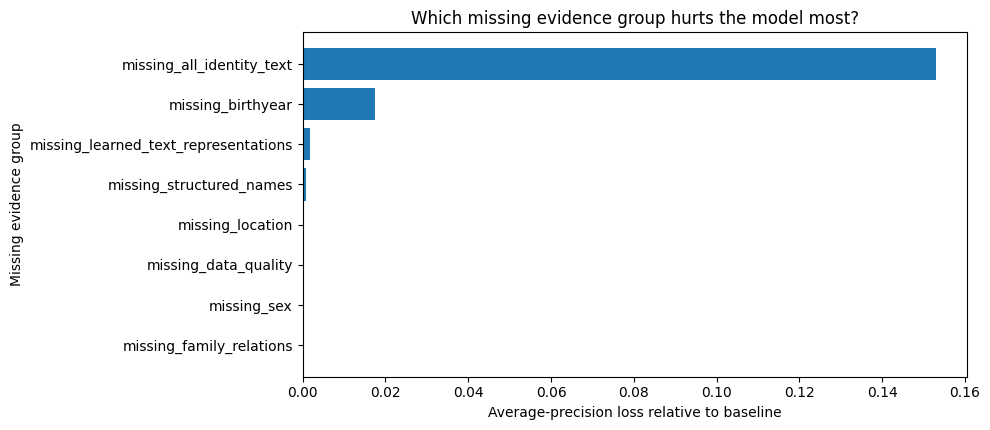


Individual derived-feature impact:


,impact_rank,feature,average_precision_loss,roc_auc_loss,fixed_f1_loss,brier_increase,fixed_precision,fixed_recall
0,1,birthyear_sim,0.0008,0.0002,0.0050,0.0029,0.9852,0.9886
1,2,first_name_sim,0.0008,0.0002,0.0028,0.0024,0.9936,0.9846
2,3,record_text_sim,0.0003,0.0001,0.0009,0.0001,0.9899,0.9921
3,4,embedding_cosine,0.0002,0.0000,0.0005,0.0013,0.9926,0.9904
4,5,full_name_sim,0.0002,0.0000,0.0215,0.0145,0.9967,0.9456
5,6,family_name_max_sim,0.0001,0.0000,0.0002,0.0007,0.9929,0.9905
6,7,location_hierarchy,0.0001,0.0000,0.0012,0.0001,0.9889,0.9926
7,8,char_tfidf_cosine,0.0001,0.0000,0.0008,0.0014,0.9930,0.9892
8,9,county_match,0.0001,0.0000,0.0003,0.0000,0.9915,0.9918
9,10,district_match,0.0000,0.0000,0.0014,0.0001,0.9883,0.9928


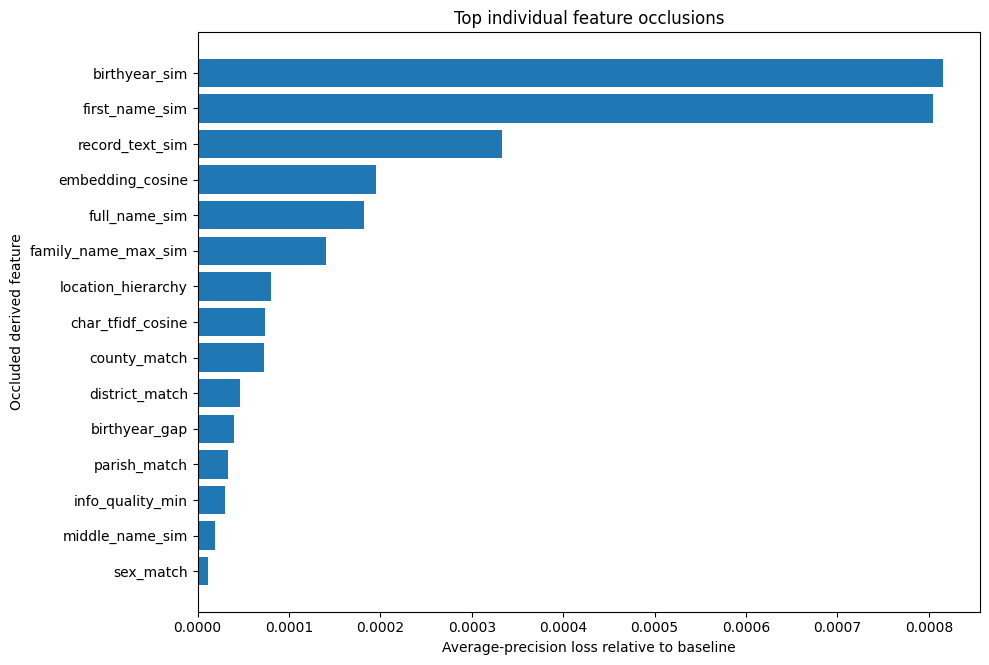


Saved feature-ablation outputs:
  artifacts/gpu_pipeline_v5_5_optimized/feature_group_missingness_ablation.csv
  artifacts/gpu_pipeline_v5_5_optimized/individual_feature_occlusion.csv
  artifacts/gpu_pipeline_v5_5_optimized/feature_ablation_summary.json

Interpret the first-ranked row as the evidence whose absence caused the
largest drop in average precision. Confirm with fixed-F1 loss and Brier increase.


In [20]:

# ============================================================
# FEATURE MISSINGNESS / ABLATION ANALYSIS
# Run after model training and feature-table creation.
# ============================================================
print("\n" + "=" * 72)
print("FEATURE MISSINGNESS AND ABLATION ANALYSIS")
print("=" * 72)

from pathlib import Path
from sklearn.base import clone
import matplotlib.pyplot as plt

# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------
RUN_INDIVIDUAL_FEATURE_OCCLUSION = True
RUN_RETRAIN_ABLATION = False  # Set True for a slower, stronger retraining experiment.
TOP_N_INDIVIDUAL_FEATURES_TO_DISPLAY = 20

# Evidence groups. These are derived model features, not raw source columns.
# "all_identity_text" intentionally combines explicit name similarities and
# learned text representations to approximate losing most textual identity evidence.
FEATURE_GROUPS = {
    "structured_names": [
        "full_name_sim", "first_name_sim", "middle_name_sim", "patronym_sim",
        "surname_sim", "family_name_max_sim", "maiden_to_surname_sim",
        "alias_overlap_sim",
    ],
    "learned_text_representations": [
        "char_tfidf_cosine", "embedding_cosine", "record_text_sim",
    ],
    "birthyear": [
        "birthyear_sim", "birthyear_gap", "birthyear_both_present",
        "close_2yr", "close_5yr", "close_10yr",
    ],
    "sex": [
        "sex_match", "sex_conflict", "sex_left_missing", "sex_right_missing",
    ],
    "location": [
        "county_match", "parish_match", "district_match", "farm_match",
        "location_hierarchy", "county_either_missing",
        "parish_either_missing", "farm_either_missing",
    ],
    "family_relations": [
        "father_name_sim", "mother_name_sim", "partner_name_sim",
    ],
    "data_quality": [
        "info_quality_min", "info_quality_mean", "low_information_pair",
    ],
}
FEATURE_GROUPS["all_identity_text"] = sorted(set(
    FEATURE_GROUPS["structured_names"] + FEATURE_GROUPS["learned_text_representations"]
))

# Keep only columns that exist in this notebook version.
FEATURE_GROUPS = {
    group: [column for column in columns if column in FEATURE_COLUMNS]
    for group, columns in FEATURE_GROUPS.items()
}
FEATURE_GROUPS = {group: columns for group, columns in FEATURE_GROUPS.items() if columns}

# Values that mimic the feature representation used when raw evidence is absent.
SEMANTIC_MISSING_VALUES = {
    "birthyear_sim": 0.0,
    "birthyear_gap": 999.0,
    "birthyear_both_present": 0.0,
    "close_2yr": 0.0,
    "close_5yr": 0.0,
    "close_10yr": 0.0,
    "sex_match": 0.0,
    "sex_conflict": 0.0,
    "sex_left_missing": 1.0,
    "sex_right_missing": 1.0,
    "county_match": 0.0,
    "parish_match": 0.0,
    "district_match": 0.0,
    "farm_match": 0.0,
    "location_hierarchy": 0.0,
    "county_either_missing": 1.0,
    "parish_either_missing": 1.0,
    "farm_either_missing": 1.0,
}

_train_feature_frame = (
    feature_tables["train"][FEATURE_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .astype(np.float32)
)
_feature_medians = _train_feature_frame.median(axis=0).to_dict()
_feature_index = {feature: index for index, feature in enumerate(FEATURE_COLUMNS)}

# Baseline deployment threshold: select it on validation once, then keep it fixed.
_baseline_validation_prob = predict_calibrated(X_valid)
BASELINE_FIXED_THRESHOLD = _best_f1_metrics(
    y_valid, _baseline_validation_prob
)["threshold"]


def _safe_auc(y_true, probabilities):
    return (
        float(roc_auc_score(y_true, probabilities))
        if np.unique(y_true).size > 1 else np.nan
    )


def _safe_average_precision(y_true, probabilities):
    return (
        float(average_precision_score(y_true, probabilities))
        if np.unique(y_true).size > 1 else np.nan
    )


def _fixed_threshold_metrics(y_true, probabilities, threshold):
    predictions = probabilities >= threshold
    selected = int(predictions.sum())
    high_conf_precision = (
        float(precision_score(y_true, predictions, zero_division=0))
        if selected else np.nan
    )
    return {
        "fixed_threshold": float(threshold),
        "fixed_precision": float(precision_score(y_true, predictions, zero_division=0)),
        "fixed_recall": float(recall_score(y_true, predictions, zero_division=0)),
        "fixed_f1": float(f1_score(y_true, predictions, zero_division=0)),
        "predicted_match_rate": float(predictions.mean()),
        "predicted_match_count": selected,
        "high_conf_precision": high_conf_precision,
    }


def _evaluate_probability_vector(condition, probabilities, y_true=y_test):
    probabilities = np.asarray(probabilities, dtype=float)
    result = {
        "condition": condition,
        "roc_auc": _safe_auc(y_true, probabilities),
        "average_precision": _safe_average_precision(y_true, probabilities),
        "brier": float(brier_score_loss(y_true, probabilities)),
        "mean_probability": float(probabilities.mean()),
        "mean_positive_probability": float(probabilities[y_true == 1].mean()),
        "mean_negative_probability": float(probabilities[y_true == 0].mean()),
    }
    result.update(
        _fixed_threshold_metrics(
            y_true, probabilities, BASELINE_FIXED_THRESHOLD
        )
    )
    return result


def _mask_feature_group(X, columns):
    """Mask a semantic evidence group in a copy of a feature matrix."""
    masked = np.ascontiguousarray(np.asarray(X, dtype=np.float32).copy())
    for column in columns:
        if column not in _feature_index:
            continue
        column_index = _feature_index[column]
        if column in SEMANTIC_MISSING_VALUES:
            replacement = SEMANTIC_MISSING_VALUES[column]
        elif column in {"info_quality_min", "info_quality_mean"}:
            # Quality is metadata about availability, so use a neutral training median.
            replacement = float(_feature_medians[column])
        elif column == "low_information_pair":
            replacement = 0.0
        else:
            # Similarities become zero when that evidence is unavailable.
            replacement = 0.0
        masked[:, column_index] = np.float32(replacement)
    return masked


def _mask_single_feature_neutrally(X, feature):
    """Occlude one derived feature without pretending an entire raw field is absent."""
    masked = np.ascontiguousarray(np.asarray(X, dtype=np.float32).copy())
    masked[:, _feature_index[feature]] = np.float32(_feature_medians[feature])
    return masked


# ----------------------------------------------------------------
# Experiment A: fixed-model missingness
# This directly answers: what happens if evidence is absent at inference time?
# ----------------------------------------------------------------
baseline_probabilities = predict_calibrated(X_test)
baseline_result = _evaluate_probability_vector("baseline_all_features", baseline_probabilities)

group_rows = [baseline_result]
for group_name, group_columns in FEATURE_GROUPS.items():
    masked_X = _mask_feature_group(X_test, group_columns)
    masked_probabilities = predict_calibrated(masked_X)
    row = _evaluate_probability_vector(
        f"missing_{group_name}", masked_probabilities
    )
    row["removed_features"] = ", ".join(group_columns)
    row["removed_feature_count"] = len(group_columns)
    group_rows.append(row)

group_missingness_results = pd.DataFrame(group_rows)
_baseline_group_row = group_missingness_results.iloc[0]

group_missingness_results["average_precision_loss"] = (
    float(_baseline_group_row["average_precision"])
    - group_missingness_results["average_precision"]
)
group_missingness_results["roc_auc_loss"] = (
    float(_baseline_group_row["roc_auc"])
    - group_missingness_results["roc_auc"]
)
group_missingness_results["fixed_f1_loss"] = (
    float(_baseline_group_row["fixed_f1"])
    - group_missingness_results["fixed_f1"]
)
group_missingness_results["brier_increase"] = (
    group_missingness_results["brier"]
    - float(_baseline_group_row["brier"])
)
group_missingness_results["positive_probability_drop"] = (
    float(_baseline_group_row["mean_positive_probability"])
    - group_missingness_results["mean_positive_probability"]
)

group_missingness_ranking = (
    group_missingness_results[
        group_missingness_results["condition"] != "baseline_all_features"
    ]
    .sort_values(
        ["average_precision_loss", "fixed_f1_loss", "brier_increase"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)
group_missingness_ranking.insert(
    0, "impact_rank", np.arange(1, len(group_missingness_ranking) + 1)
)

print("\nGroup-level missingness impact (larger loss = more damaging):")
display_columns = [
    "impact_rank", "condition", "removed_feature_count",
    "average_precision_loss", "roc_auc_loss", "fixed_f1_loss",
    "brier_increase", "fixed_precision", "fixed_recall",
    "predicted_match_rate",
]
display(group_missingness_ranking[display_columns].round(4))

plt.figure(figsize=(10, max(4, 0.55 * len(group_missingness_ranking))))
_plot_group = group_missingness_ranking.sort_values("average_precision_loss")
plt.barh(_plot_group["condition"], _plot_group["average_precision_loss"])
plt.xlabel("Average-precision loss relative to baseline")
plt.ylabel("Missing evidence group")
plt.title("Which missing evidence group hurts the model most?")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------
# Experiment B: individual derived-feature occlusion
# This identifies reliance on one model input at a time. Correlated features can
# hide one another, so group-level results should be treated as the primary result.
# ----------------------------------------------------------------
individual_feature_occlusion_results = pd.DataFrame()

if RUN_INDIVIDUAL_FEATURE_OCCLUSION:
    individual_rows = []
    for feature in FEATURE_COLUMNS:
        masked_X = _mask_single_feature_neutrally(X_test, feature)
        probabilities = predict_calibrated(masked_X)
        row = _evaluate_probability_vector(
            f"occlude_{feature}", probabilities
        )
        row["feature"] = feature
        individual_rows.append(row)

    individual_feature_occlusion_results = pd.DataFrame(individual_rows)
    individual_feature_occlusion_results["average_precision_loss"] = (
        baseline_result["average_precision"]
        - individual_feature_occlusion_results["average_precision"]
    )
    individual_feature_occlusion_results["roc_auc_loss"] = (
        baseline_result["roc_auc"]
        - individual_feature_occlusion_results["roc_auc"]
    )
    individual_feature_occlusion_results["fixed_f1_loss"] = (
        baseline_result["fixed_f1"]
        - individual_feature_occlusion_results["fixed_f1"]
    )
    individual_feature_occlusion_results["brier_increase"] = (
        individual_feature_occlusion_results["brier"]
        - baseline_result["brier"]
    )
    individual_feature_occlusion_results = (
        individual_feature_occlusion_results
        .sort_values(
            ["average_precision_loss", "fixed_f1_loss", "brier_increase"],
            ascending=[False, False, False],
        )
        .reset_index(drop=True)
    )
    individual_feature_occlusion_results.insert(
        0, "impact_rank",
        np.arange(1, len(individual_feature_occlusion_results) + 1)
    )

    print("\nIndividual derived-feature impact:")
    display(
        individual_feature_occlusion_results[
            [
                "impact_rank", "feature", "average_precision_loss",
                "roc_auc_loss", "fixed_f1_loss", "brier_increase",
                "fixed_precision", "fixed_recall",
            ]
        ]
        .head(TOP_N_INDIVIDUAL_FEATURES_TO_DISPLAY)
        .round(4)
    )

    _plot_individual = (
        individual_feature_occlusion_results
        .head(min(15, len(individual_feature_occlusion_results)))
        .sort_values("average_precision_loss")
    )
    plt.figure(figsize=(10, max(5, 0.45 * len(_plot_individual))))
    plt.barh(
        _plot_individual["feature"],
        _plot_individual["average_precision_loss"],
    )
    plt.xlabel("Average-precision loss relative to baseline")
    plt.ylabel("Occluded derived feature")
    plt.title("Top individual feature occlusions")
    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------------
# Experiment C (optional): drop a feature group, retrain, recalibrate, evaluate.
# This answers: can the model learn to compensate if this evidence is always absent?
# ----------------------------------------------------------------
retrained_group_ablation_results = pd.DataFrame()

def _fit_selected_model_on_columns(kept_columns):
    train_columns = [FEATURE_COLUMNS.index(column) for column in kept_columns]
    Xtr = np.ascontiguousarray(X_train[:, train_columns], dtype=np.float32)
    Xca = np.ascontiguousarray(X_cal[:, train_columns], dtype=np.float32)
    Xva = np.ascontiguousarray(X_valid[:, train_columns], dtype=np.float32)
    Xte = np.ascontiguousarray(X_test[:, train_columns], dtype=np.float32)

    estimator = clone(MODEL_SPECS[selected_model_name]["estimator"])
    fit_kwargs = (
        {"classifier__sample_weight": w_train}
        if selected_model_name == "LogisticRegression"
        else {"sample_weight": w_train}
    )

    try:
        estimator.fit(Xtr, y_train, **fit_kwargs)
    except Exception as exc:
        if selected_model_name == "LightGBM" and USE_GPU:
            print(f"  LightGBM GPU ablation fallback: {str(exc)[:140]}")
            estimator.set_params(
                device_type="cpu", gpu_device_id=-1, max_bin=255, n_jobs=-1
            )
            estimator.fit(Xtr, y_train, **fit_kwargs)
        elif selected_model_name == "XGBoost" and USE_GPU:
            print(f"  XGBoost GPU ablation fallback: {str(exc)[:140]}")
            estimator.set_params(device="cpu")
            estimator.fit(Xtr, y_train, **fit_kwargs)
        else:
            raise

    raw_calibration_scores = _raw_model_score(estimator, Xca)
    local_calibrator = LogisticRegression(
        C=1.0, solver="lbfgs", random_state=RANDOM_STATE
    )
    local_calibrator.fit(
        raw_calibration_scores.reshape(-1, 1),
        y_cal,
        sample_weight=w_cal,
    )

    validation_probabilities = _calibrated_probabilities(
        estimator, local_calibrator, Xva
    )
    test_probabilities = _calibrated_probabilities(
        estimator, local_calibrator, Xte
    )
    threshold = _best_f1_metrics(
        y_valid, validation_probabilities
    )["threshold"]

    result = {
        "roc_auc": _safe_auc(y_test, test_probabilities),
        "average_precision": _safe_average_precision(y_test, test_probabilities),
        "brier": float(brier_score_loss(y_test, test_probabilities)),
    }
    result.update(
        _fixed_threshold_metrics(y_test, test_probabilities, threshold)
    )
    return result


if RUN_RETRAIN_ABLATION:
    retrain_rows = []
    for group_name, removed_columns in FEATURE_GROUPS.items():
        kept_columns = [
            column for column in FEATURE_COLUMNS
            if column not in set(removed_columns)
        ]
        print(
            f"Retraining {selected_model_name} without {group_name} "
            f"({len(removed_columns)} features removed)..."
        )
        row = _fit_selected_model_on_columns(kept_columns)
        row["condition"] = f"retrained_without_{group_name}"
        row["removed_feature_count"] = len(removed_columns)
        row["removed_features"] = ", ".join(removed_columns)
        retrain_rows.append(row)

    retrained_group_ablation_results = pd.DataFrame(retrain_rows)
    retrained_group_ablation_results["average_precision_loss"] = (
        baseline_result["average_precision"]
        - retrained_group_ablation_results["average_precision"]
    )
    retrained_group_ablation_results["roc_auc_loss"] = (
        baseline_result["roc_auc"]
        - retrained_group_ablation_results["roc_auc"]
    )
    retrained_group_ablation_results["fixed_f1_loss"] = (
        baseline_result["fixed_f1"]
        - retrained_group_ablation_results["fixed_f1"]
    )
    retrained_group_ablation_results["brier_increase"] = (
        retrained_group_ablation_results["brier"]
        - baseline_result["brier"]
    )
    retrained_group_ablation_results = (
        retrained_group_ablation_results
        .sort_values(
            ["average_precision_loss", "fixed_f1_loss", "brier_increase"],
            ascending=[False, False, False],
        )
        .reset_index(drop=True)
    )
    retrained_group_ablation_results.insert(
        0, "impact_rank",
        np.arange(1, len(retrained_group_ablation_results) + 1)
    )
    print("\nRetrained group-ablation impact:")
    display(retrained_group_ablation_results.round(4))


# ----------------------------------------------------------------
# Save outputs
# ----------------------------------------------------------------
_ablation_output_dir = Path(OUTPUT_DIR)
_ablation_output_dir.mkdir(parents=True, exist_ok=True)

group_path = _ablation_output_dir / "feature_group_missingness_ablation.csv"
individual_path = _ablation_output_dir / "individual_feature_occlusion.csv"
retrained_path = _ablation_output_dir / "retrained_feature_group_ablation.csv"

group_missingness_results.to_csv(group_path, index=False)
if not individual_feature_occlusion_results.empty:
    individual_feature_occlusion_results.to_csv(individual_path, index=False)
if not retrained_group_ablation_results.empty:
    retrained_group_ablation_results.to_csv(retrained_path, index=False)

feature_ablation_summary = {
    "selected_model": selected_model_name,
    "baseline_fixed_threshold_from_validation": float(BASELINE_FIXED_THRESHOLD),
    "primary_ranking_metric": "average_precision_loss",
    "group_results_csv": str(group_path),
    "individual_results_csv": (
        str(individual_path)
        if not individual_feature_occlusion_results.empty else None
    ),
    "retrained_results_csv": (
        str(retrained_path)
        if not retrained_group_ablation_results.empty else None
    ),
    "interpretation": {
        "fixed_model_missingness": (
            "Immediate production impact when evidence disappears after training."
        ),
        "retrained_ablation": (
            "Residual impact after retraining without that evidence; enable "
            "RUN_RETRAIN_ABLATION to run it."
        ),
        "positive_loss": (
            "A positive loss means performance became worse than the baseline."
        ),
        "negative_loss": (
            "A small negative loss can occur from sampling noise or redundant/noisy evidence."
        ),
    },
}

summary_path = _ablation_output_dir / "feature_ablation_summary.json"
with open(summary_path, "w", encoding="utf-8") as file:
    json.dump(feature_ablation_summary, file, indent=2)

print("\nSaved feature-ablation outputs:")
print(f"  {group_path}")
if not individual_feature_occlusion_results.empty:
    print(f"  {individual_path}")
if not retrained_group_ablation_results.empty:
    print(f"  {retrained_path}")
print(f"  {summary_path}")
print("\nInterpret the first-ranked row as the evidence whose absence caused the")
print("largest drop in average precision. Confirm with fixed-F1 loss and Brier increase.")
